In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib

In [2]:
# load the dataset
covid_data=pd.read_csv('covid_19_india.csv')

In [3]:
covid_data.head()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3


In [4]:
covid_data.tail()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812
18109,18110,2021-08-11,8:00 AM,West Bengal,-,-,1506532,18252,1534999


In [3]:
# remove unnecessary column
covid_data.drop(columns=['ConfirmedIndianNational','ConfirmedForeignNational','Sno'],inplace=True)

# create pivot table of state and confirmed case
state_and_confirmed_case=covid_data.pivot_table(values='Confirmed',index='State/UnionTerritory',aggfunc='sum')

# remove the unnecessary data from total_confirmed_case dataset
state_and_confirmed_case.drop(labels=['Daman & Diu','Dadra and Nagar Haveli','Maharashtra***','Telangana','Madhya Pradesh***','Karanataka','Himanchal Pradesh','Bihar****','Cases being reassigned to states','Unassigned'],inplace=True)

# total_deaths_by_state
state_and_deaths=covid_data.pivot_table(values='Deaths',index='State/UnionTerritory',aggfunc='sum')

# remove the unnecessary data from total_death dataset
state_and_deaths.drop(labels=['Daman & Diu','Dadra and Nagar Haveli','Maharashtra***','Telangana','Madhya Pradesh***','Karanataka','Himanchal Pradesh','Bihar****','Cases being reassigned to states','Unassigned'],inplace=True)

# total_cured_people
state_and_cured=covid_data.pivot_table(values='Cured',index='State/UnionTerritory',aggfunc='sum')

# remove the unnecessary data from total_cured dataset
state_and_cured.drop(labels=['Daman & Diu','Dadra and Nagar Haveli','Maharashtra***','Telangana','Madhya Pradesh***','Karanataka','Himanchal Pradesh','Bihar****','Cases being reassigned to states','Unassigned'],inplace=True)

# confirmed case by date
confirmed_case_by_date=covid_data.pivot_table(values='Confirmed',index='Date',aggfunc='sum')

# deaths by date
death_by_date=covid_data.pivot_table(values='Deaths',index='Date',aggfunc='sum')

# cured people number by date
cured_by_date=covid_data.pivot_table(values='Cured',index='Date',aggfunc='sum')

# confirmed case by time
confirmed_case_by_time=covid_data.pivot_table(values='Confirmed',index='Time',aggfunc='sum')

# death by time
death_by_time=covid_data.pivot_table(values='Deaths',index='Time',aggfunc='sum')

# cured people number by time
cured_by_time=covid_data.pivot_table(values='Cured',index='Time',aggfunc='sum')

In [11]:
def create_barplot(data, start, end, xlabel='None', ylabel='None', title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a bar plot for the specified subset of the data, with color gradient based on the values.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        xlabel (str, optional): Label for the x-axis. Default is 'None'.
        ylabel (str, optional): Label for the y-axis. Default is 'None'.
        title (str, optional): Title of the plot. Default is 'Covid Data'.
        fig_width (int, optional): Width of the figure. Default is 20.
        fig_height (int, optional): Height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the bars. Default is 'red'.

    Returns:
        None: Displays the bar plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset.columns[0]
    
    norm = mcolors.Normalize(vmin=subset[values].min(), vmax=subset[values].max())
    cmap = matplotlib.colormaps[colormap]  
    color = [cmap(norm(value)) for value in subset[values]]
    
    sns.barplot(data=subset, x=subset.index, y=subset[values], palette=color, hue=subset.index)
    plt.title(title, fontweight='bold')
    plt.xlabel(xlabel, fontweight='bold')
    plt.ylabel(ylabel, fontweight='bold')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [4]:
def create_lineplot(data, start, end,xlabel='None',ylabel='None',title='Covid Data',fig_width=20,fig_height=10,color='red'):
    """
    Creates a line plot for the specified subset of the data, showing the trend of confirmed cases over time.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        xlabel (str, optional): Label for the x-axis. Default is 'None'.
        ylabel (str, optional): Label for the y-axis. Default is 'None'.
        title (str, optional): Title of the plot. Default is 'Covid Data'.
        fig_width (int, optional): Width of the figure. Default is 20.
        fig_height (int, optional): Height of the figure. Default is 10.
        color (str, optional): The color of the line in the plot. Default is 'red'.

    Returns:
        None: Displays the line plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width,fig_height))
    values=subset.columns[0]
    sns.lineplot(data=subset, x=subset.index, y=subset[values], marker='o', markersize=5, color=color)
    plt.title(title, fontweight='bold')
    plt.xlabel(xlabel, fontweight='bold')
    plt.ylabel(ylabel, fontweight='bold')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [5]:
def create_pieplot(data,start,end,title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a pie plot for a specified subset of data, with the colors of the slices 
    mapped based on the values of the data.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        title (str, optional): The title of the plot. Default is 'Data'.
        fig_width (int, optional): The width of the figure. Default is 20.
        fig_height (int, optional): The height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the pie slices. Default is 'Reds'.

    Returns:
        None: Displays the pie plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset[subset.columns[0]]
    
    norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
    cmap = matplotlib.cm.get_cmap(colormap)  
    color = [cmap(norm(value)) for value in values]
    
    plt.pie(values, labels=subset.index, autopct='%1.1f%%', colors=color, startangle=0,
            pctdistance=0.75, labeldistance=1.1)
    plt.title(title, fontweight='bold')
    plt.axis('equal')
    plt.show()

In [8]:
def create_scatterplot(data, start, end, xlabel='None', ylabel='None', title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a scatter plot for a specified subset of data, with the color of the points 
    based on the values of the data.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        xlabel (str, optional): The label for the x-axis. Default is 'None'.
        ylabel (str, optional): The label for the y-axis. Default is 'None'.
        title (str, optional): The title of the plot. Default is 'Data'.
        fig_width (int, optional): The width of the figure. Default is 20.
        fig_height (int, optional): The height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the points. Default is 'red'.

    Returns:
        None: Displays the scatter plot.
    """

    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset.columns[0]
    
    norm = mcolors.Normalize(vmin=subset[values].min(), vmax=subset[values].max())
    cmap = matplotlib.colormaps[colormap]  
    color = [cmap(norm(value)) for value in subset[values]]
    
    sns.scatterplot(data=subset, x=subset.index, y=subset[values], palette=color)
    plt.title(title, fontweight='bold')
    plt.xlabel(xlabel, fontweight='bold')
    plt.ylabel(ylabel, fontweight='bold')
    plt.xticks(rotation=90)
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


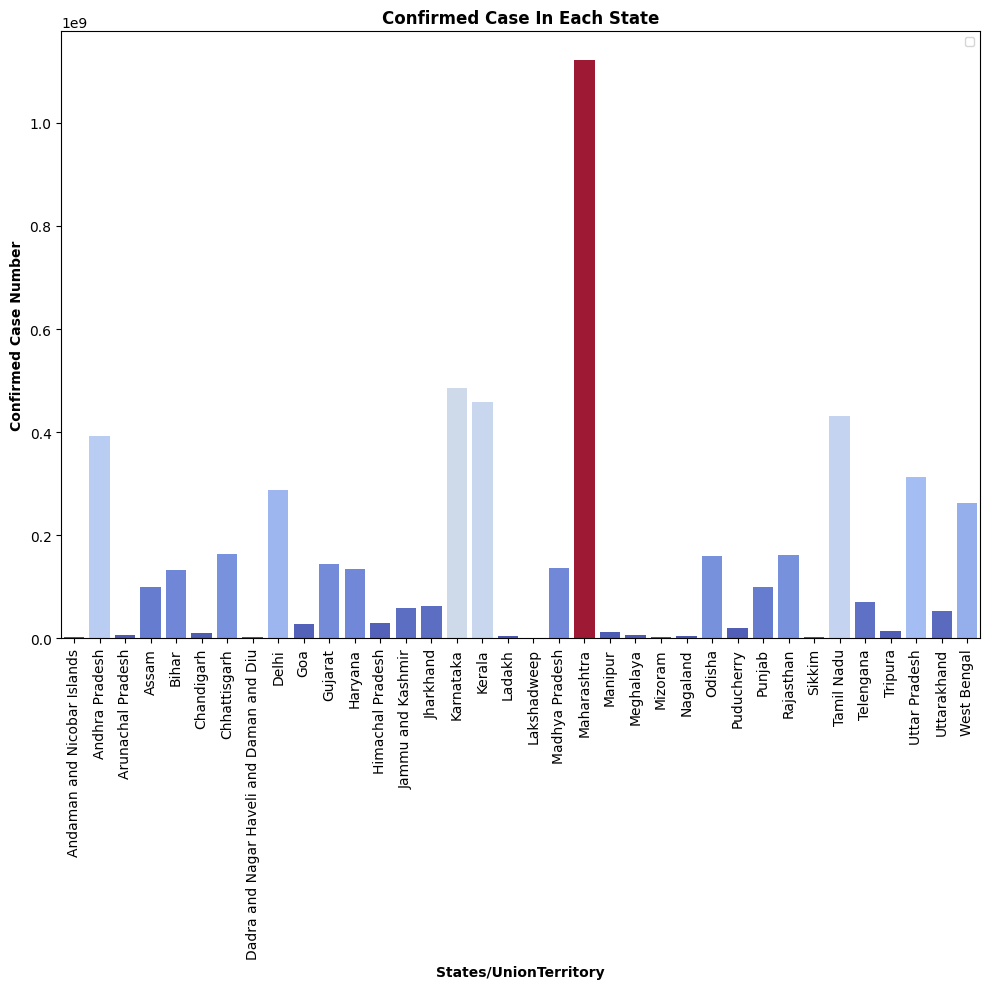

In [6]:
create_barplot(state_and_confirmed_case,0,36,'States/UnionTerritory','Confirmed Case Number','Confirmed Case In Each State',10,10,'coolwarm')

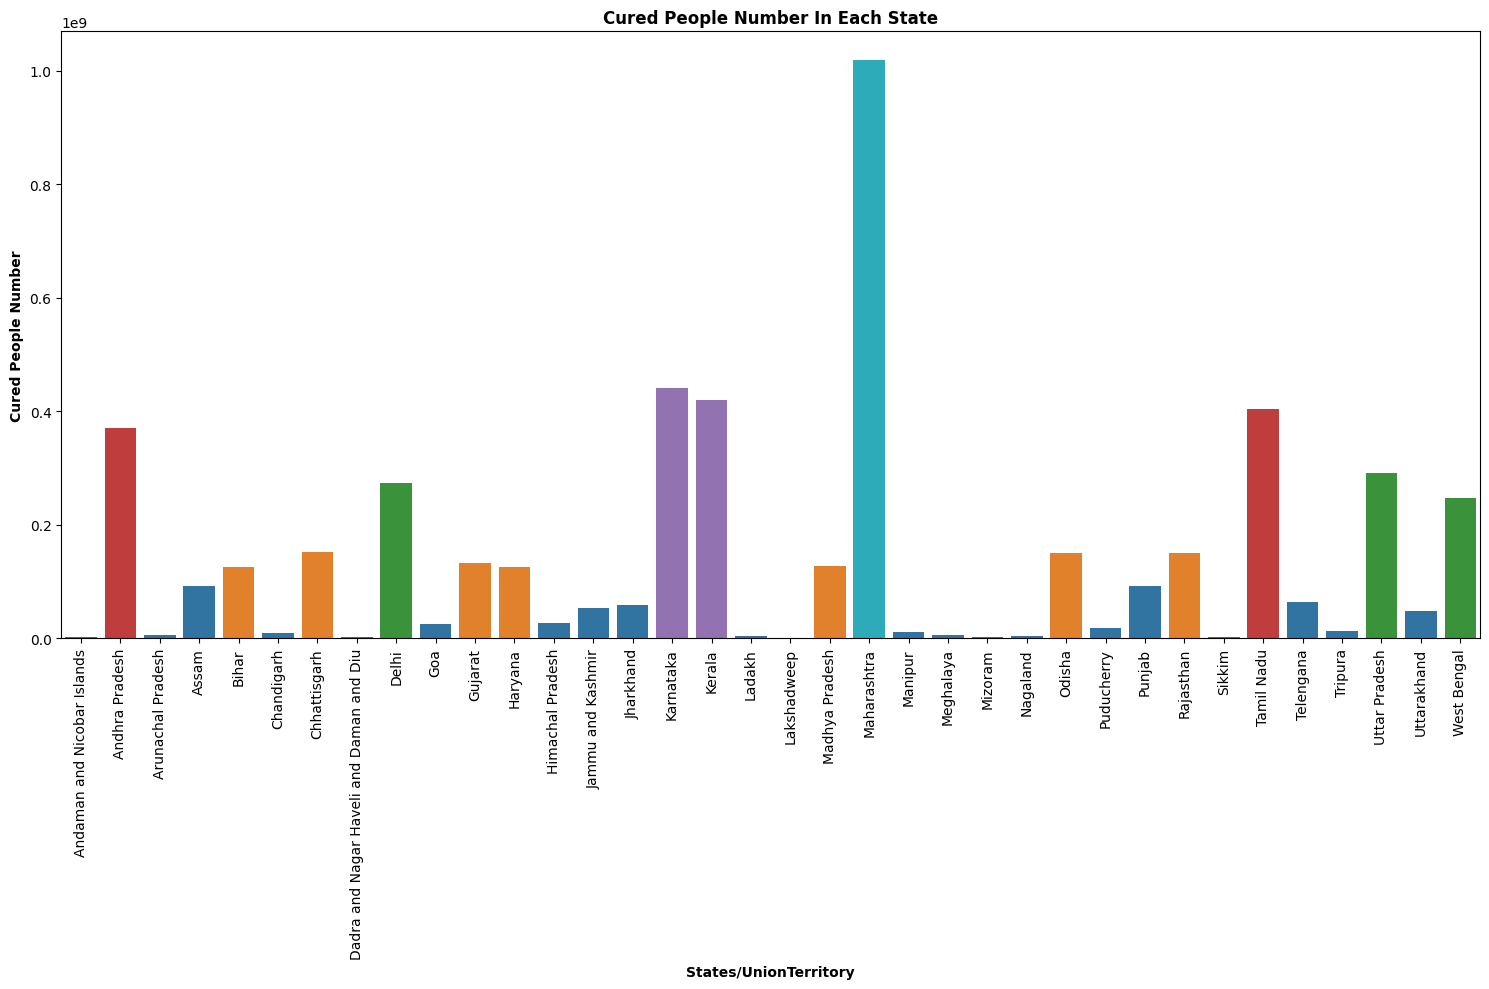

In [90]:
create_barplot(state_and_cured,0,36,'States/UnionTerritory','Cured People Number','Cured People Number In Each State',15,10,'tab10')

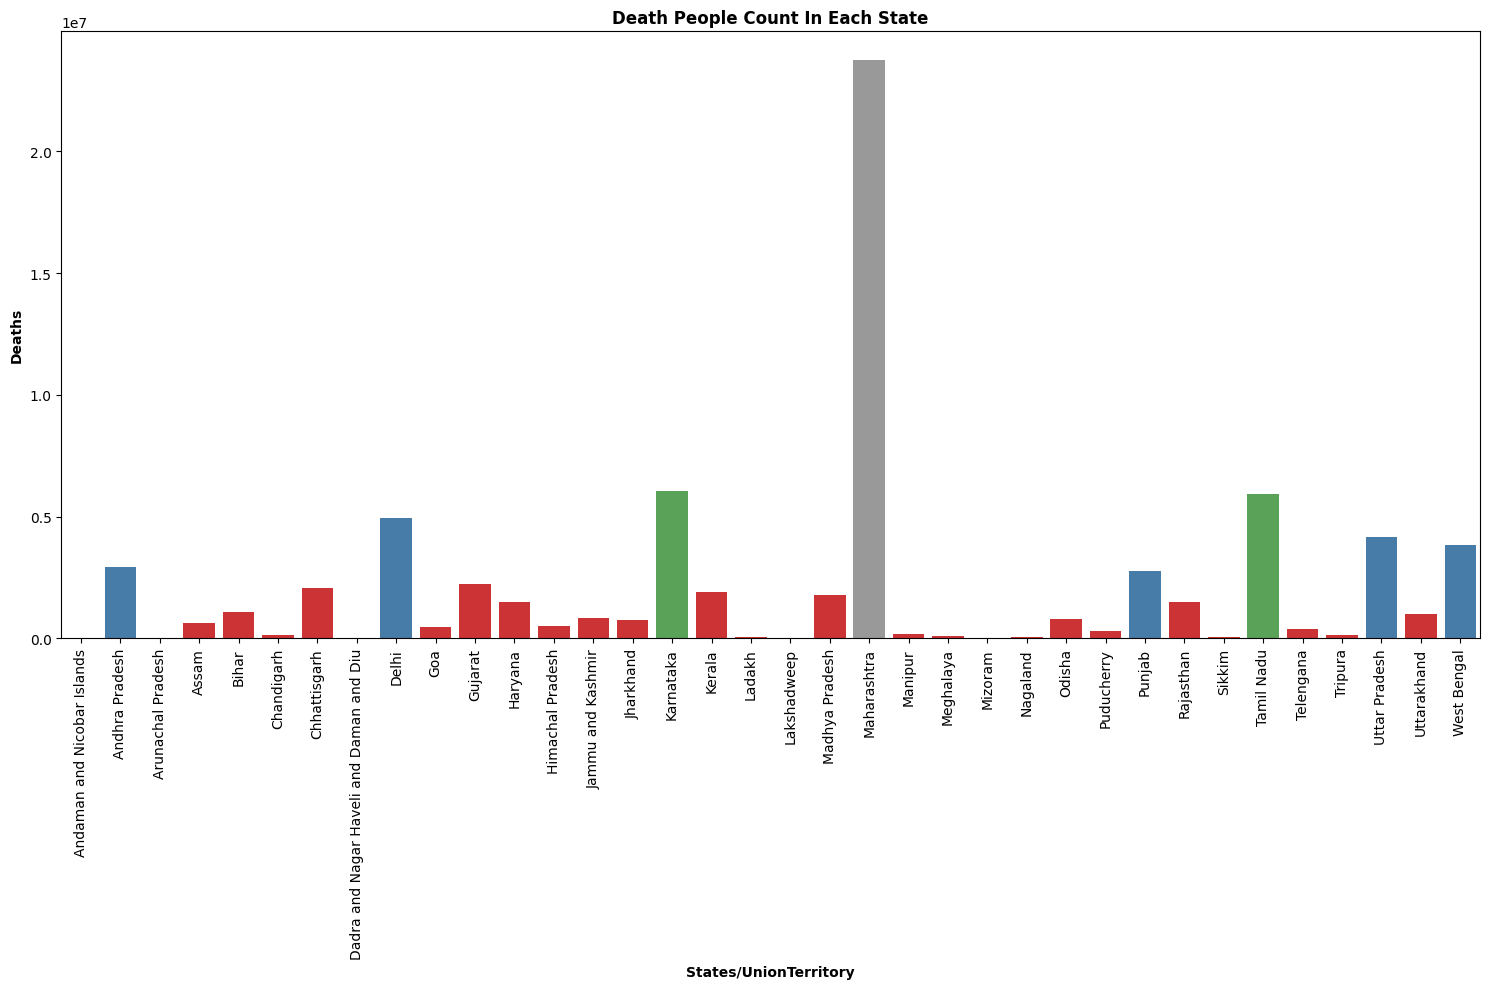

In [91]:
create_barplot(state_and_deaths,0,36,'States/UnionTerritory','Deaths','Death People Count In Each State',15,10,'Set1')

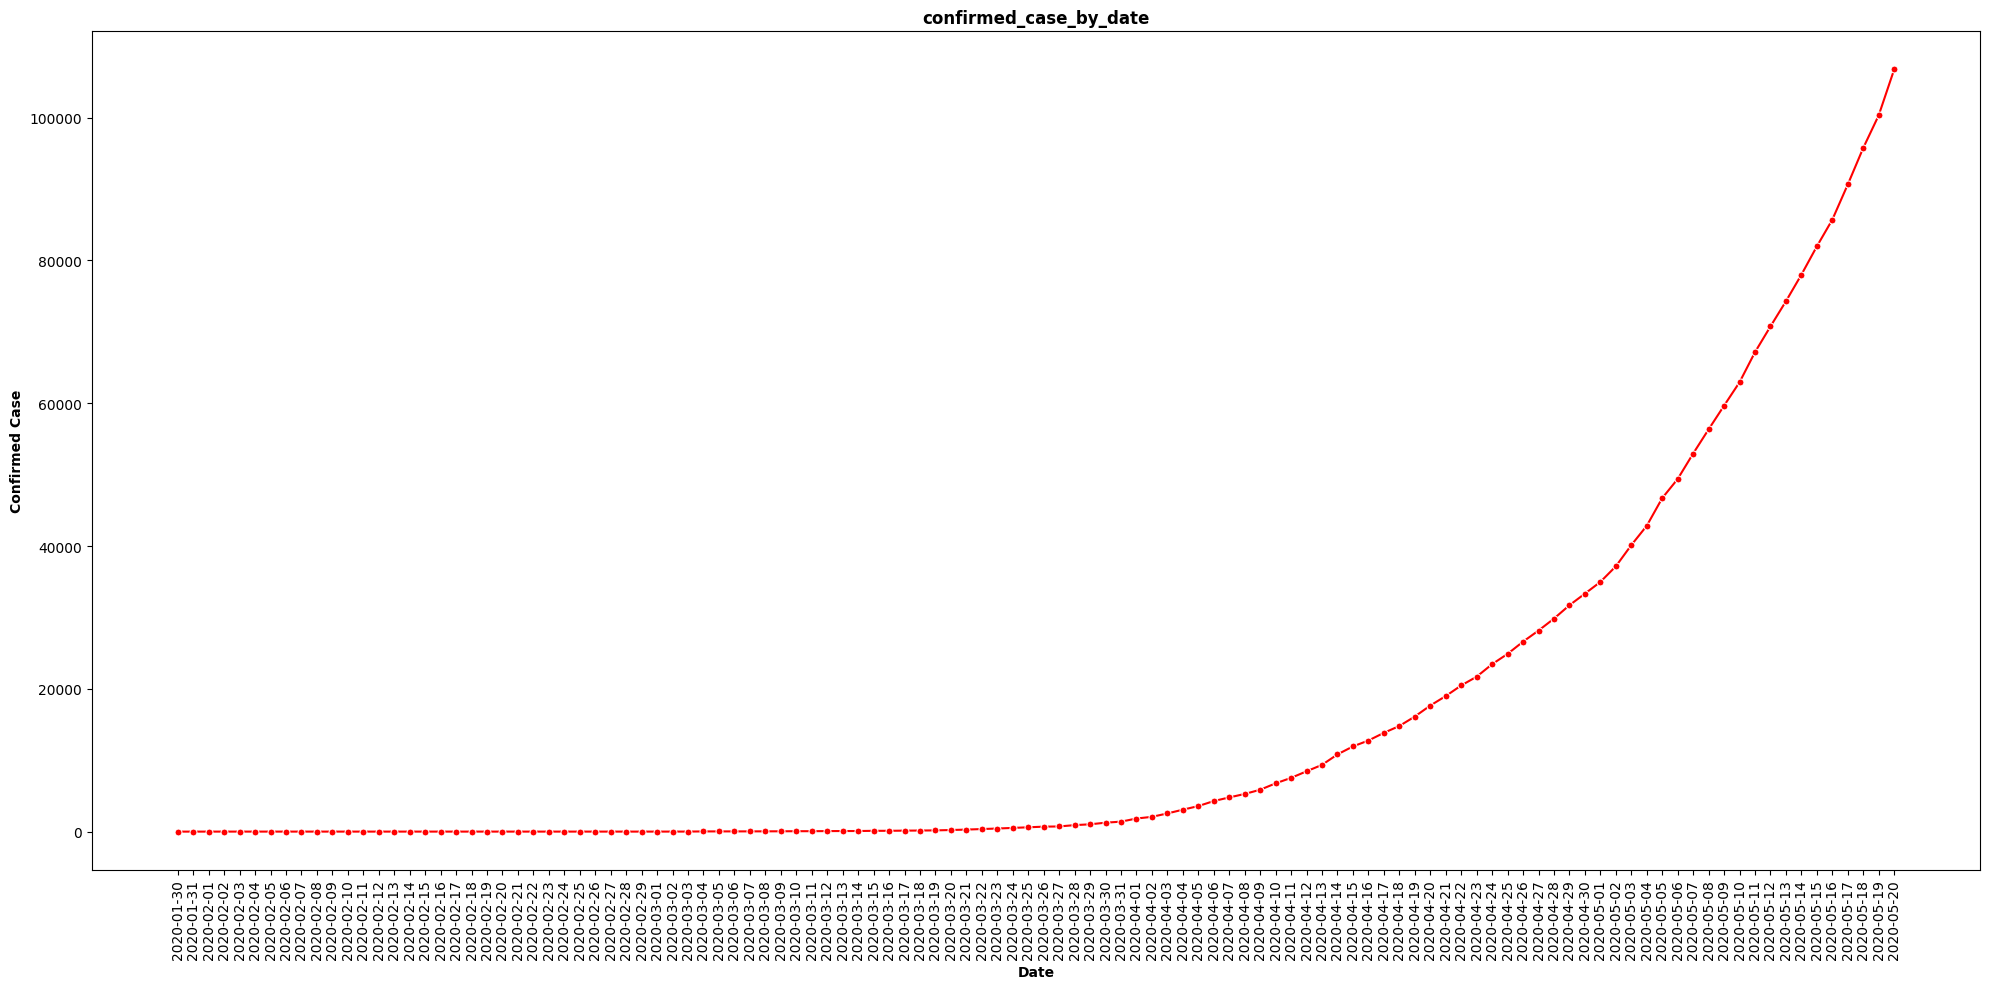

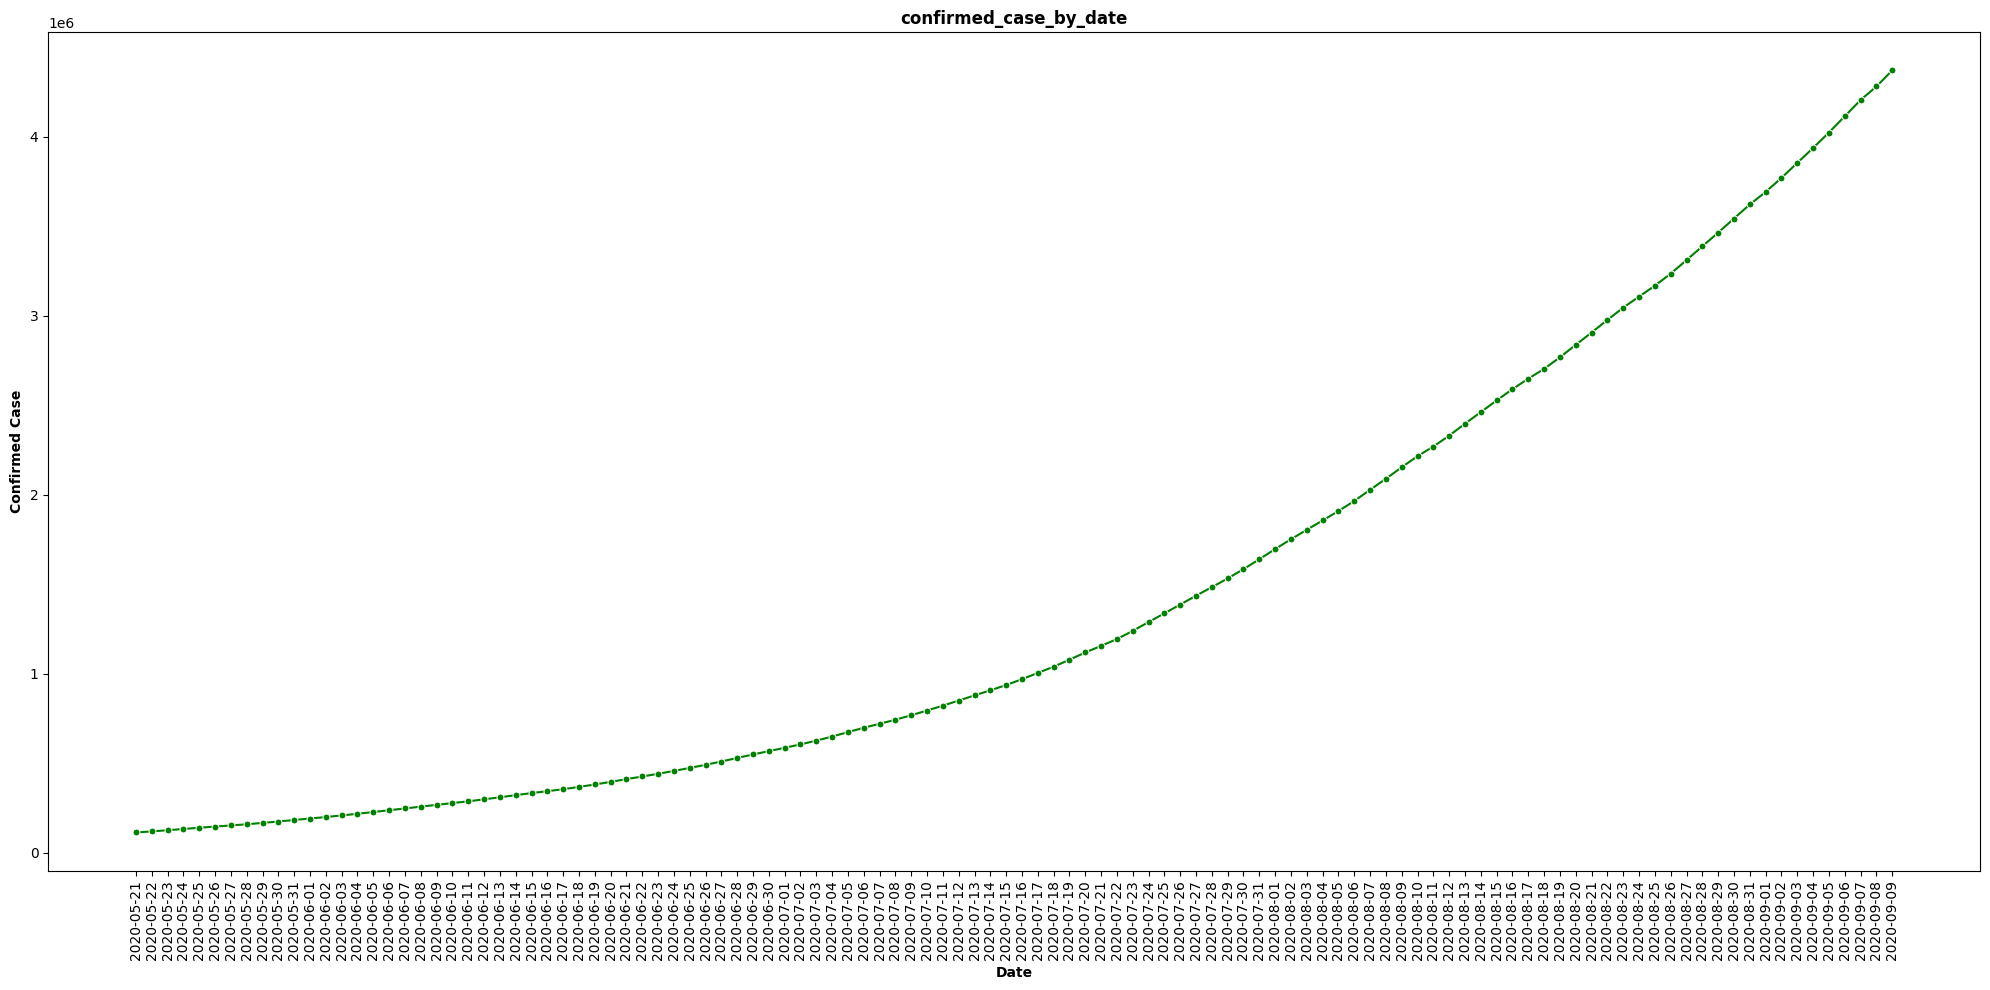

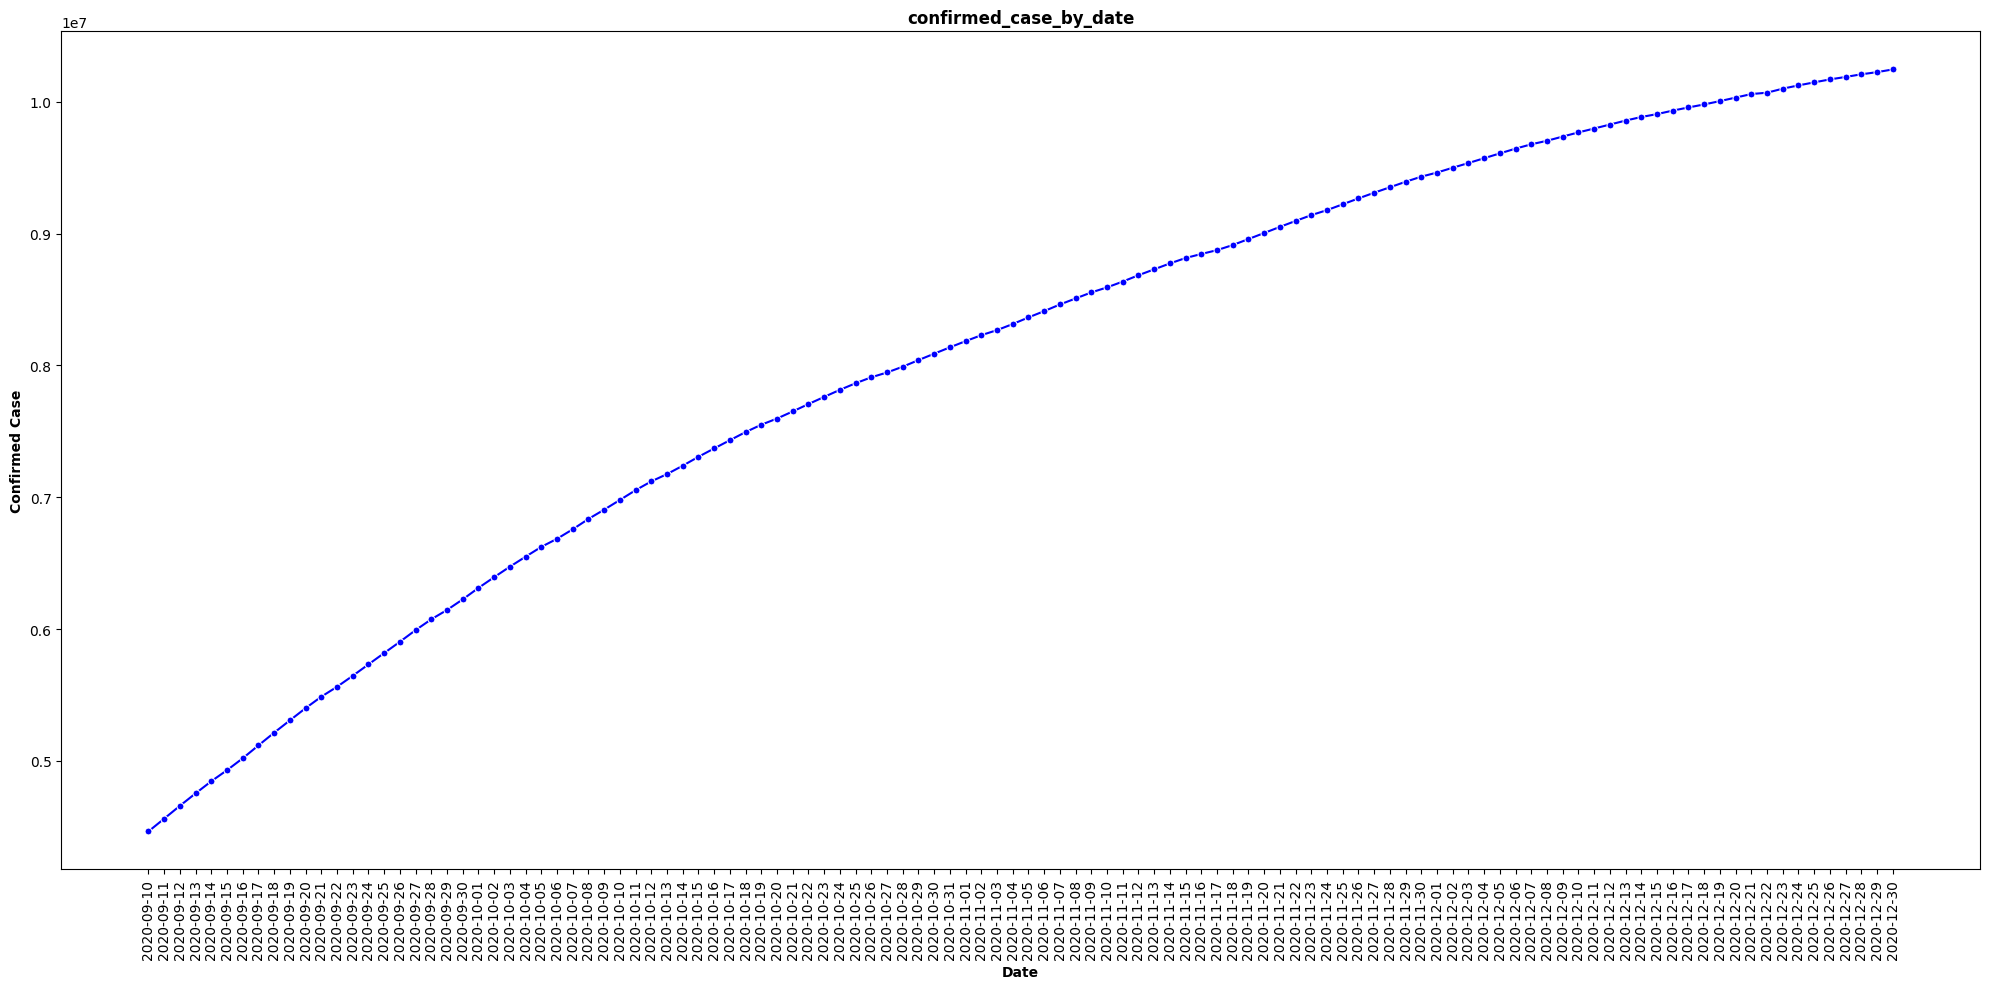

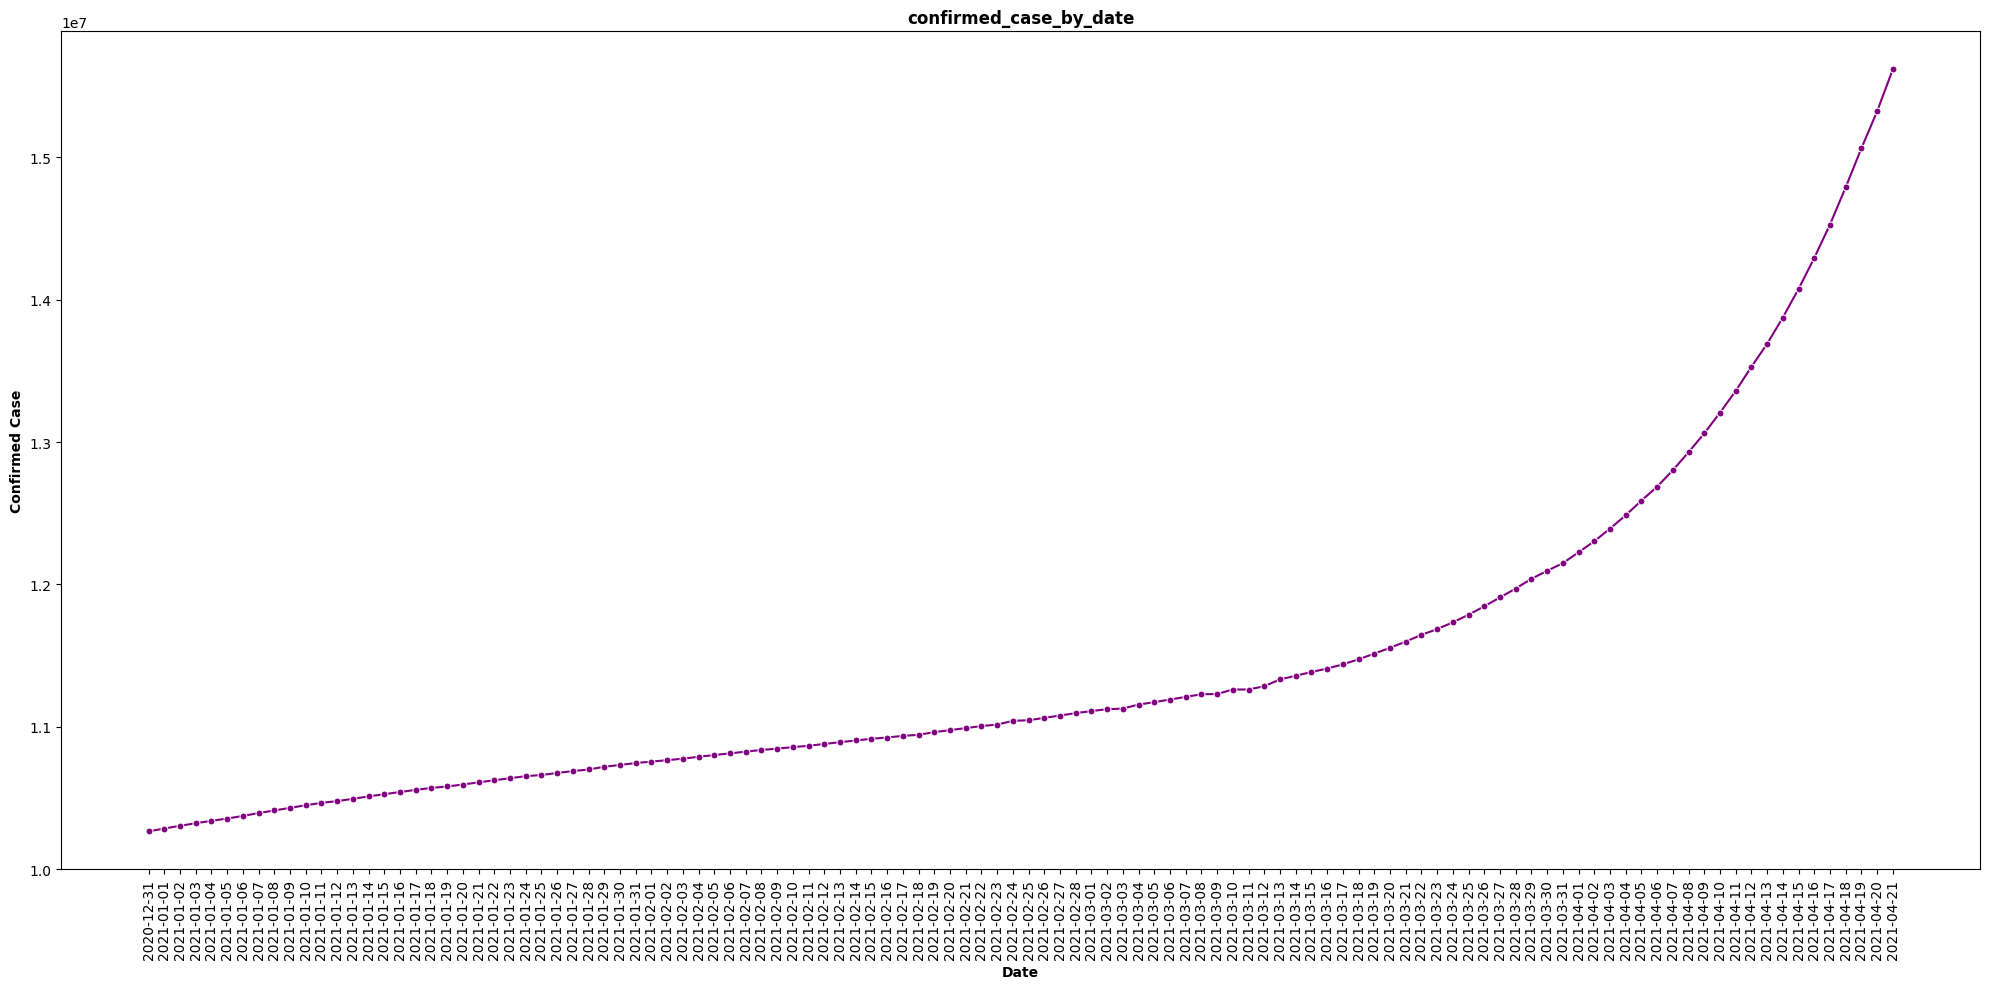

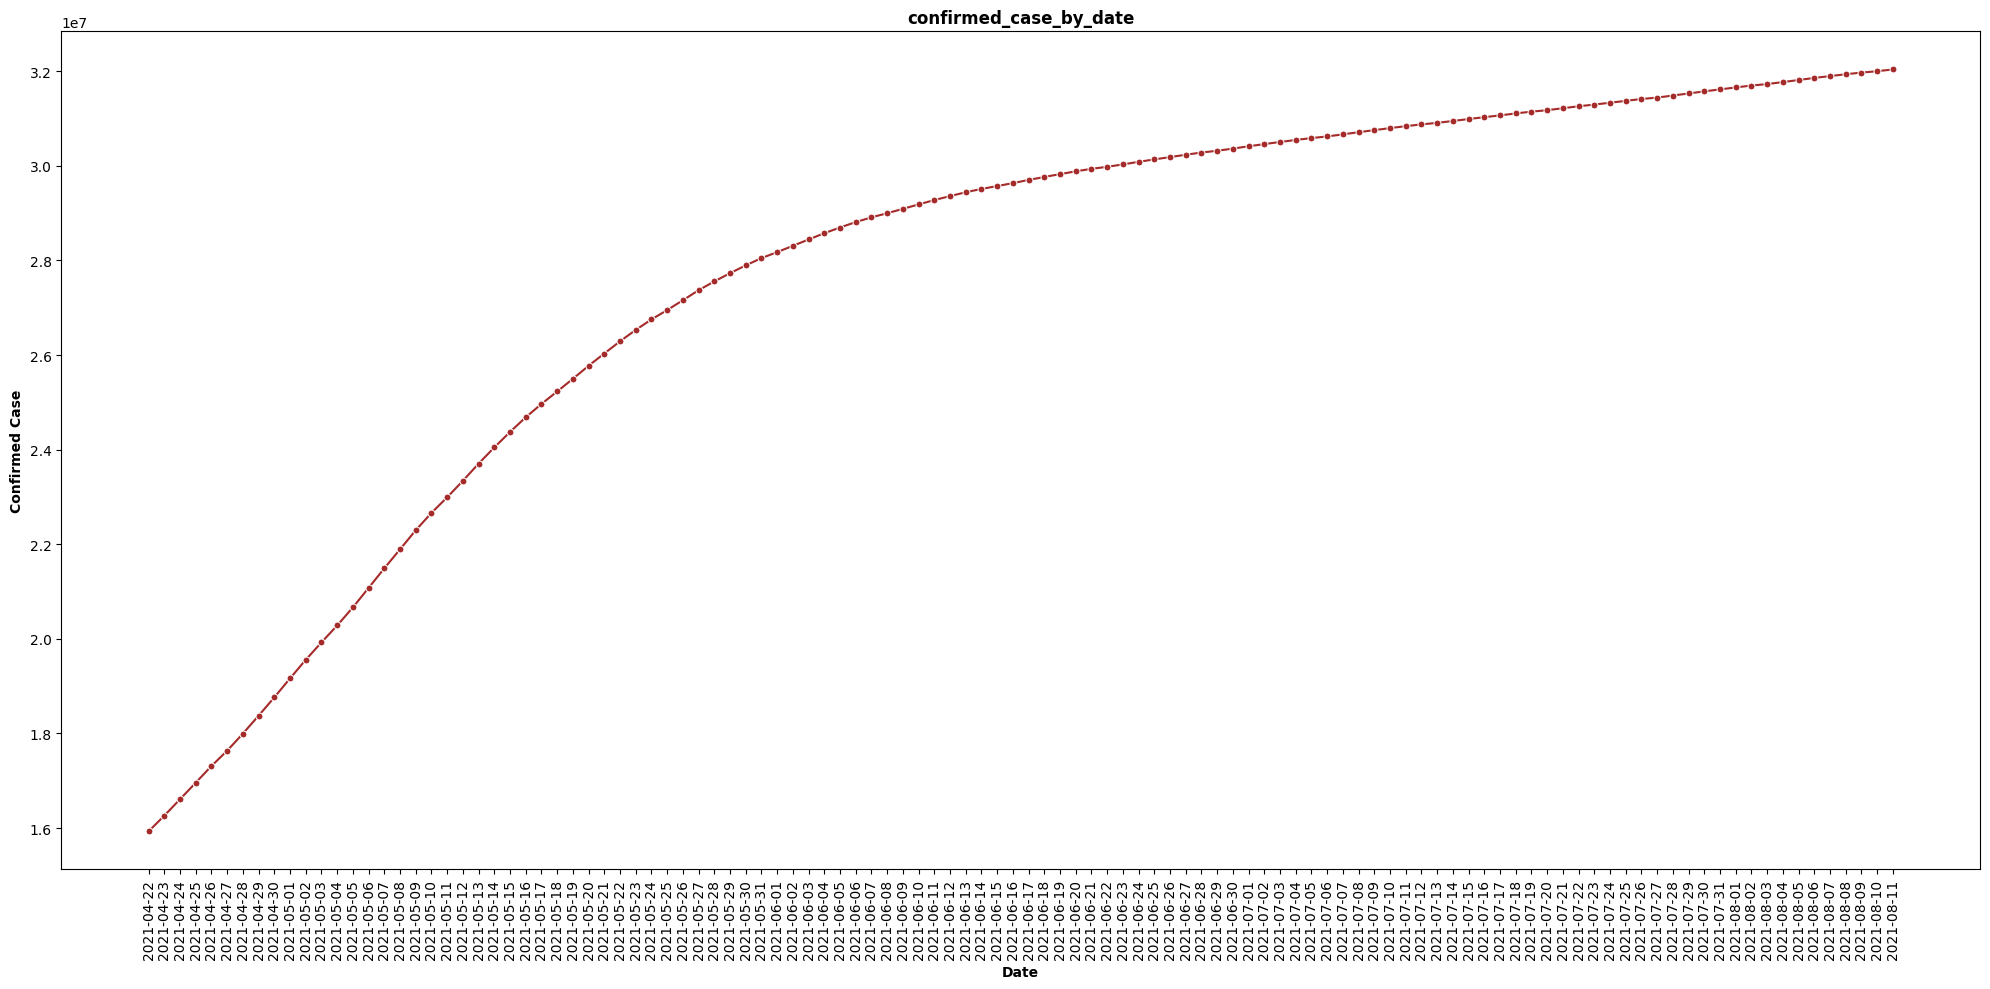

In [5]:
# Visualize the confirmed case by date data
create_lineplot(confirmed_case_by_date, 0, 112,'Date','Confirmed Case','confirmed_case_by_date',20,10,color='red')
create_lineplot(confirmed_case_by_date, 112, 224,'Date','Confirmed Case','confirmed_case_by_date',20,10,color='green')
create_lineplot(confirmed_case_by_date, 224, 336,'Date','Confirmed Case','confirmed_case_by_date',20,10,color='blue')
create_lineplot(confirmed_case_by_date, 336, 448,'Date','Confirmed Case','confirmed_case_by_date',20,10,color='purple')
create_lineplot(confirmed_case_by_date, 448, 560,'Date','Confirmed Case','confirmed_case_by_date',20,10,color='brown')

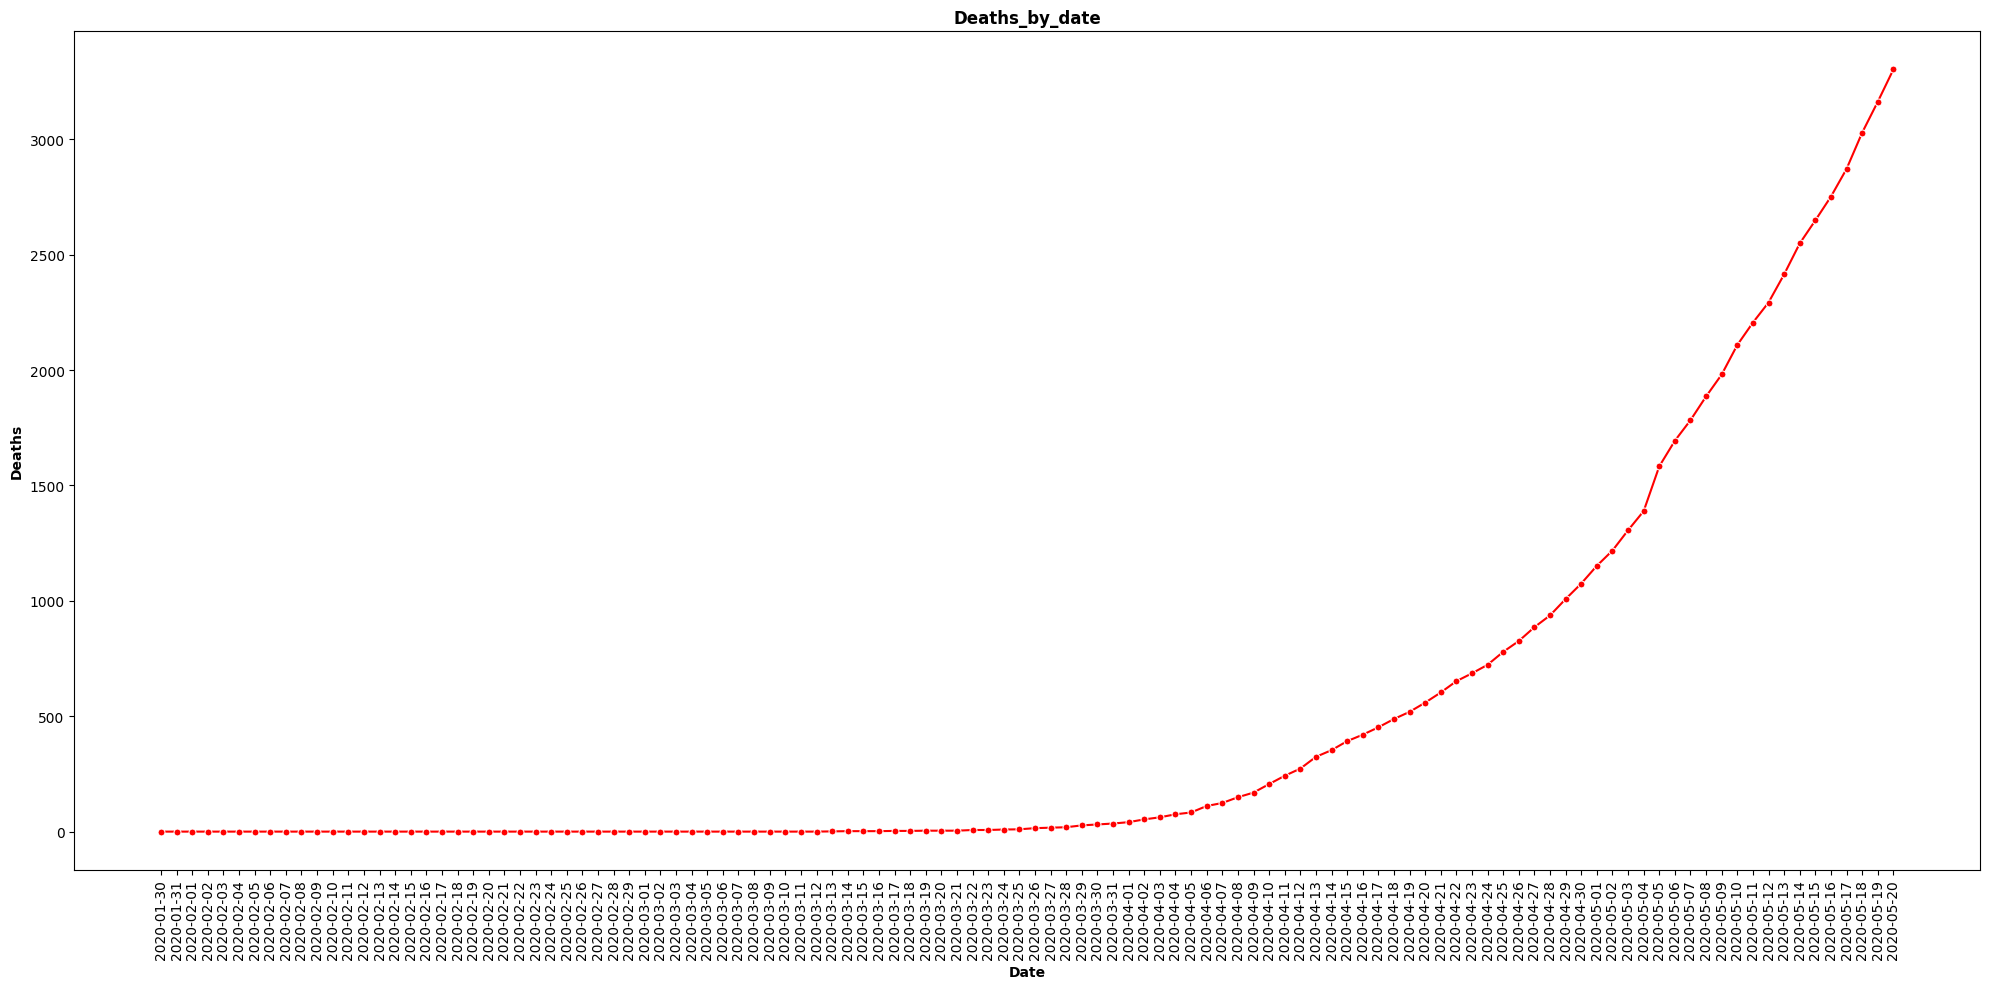

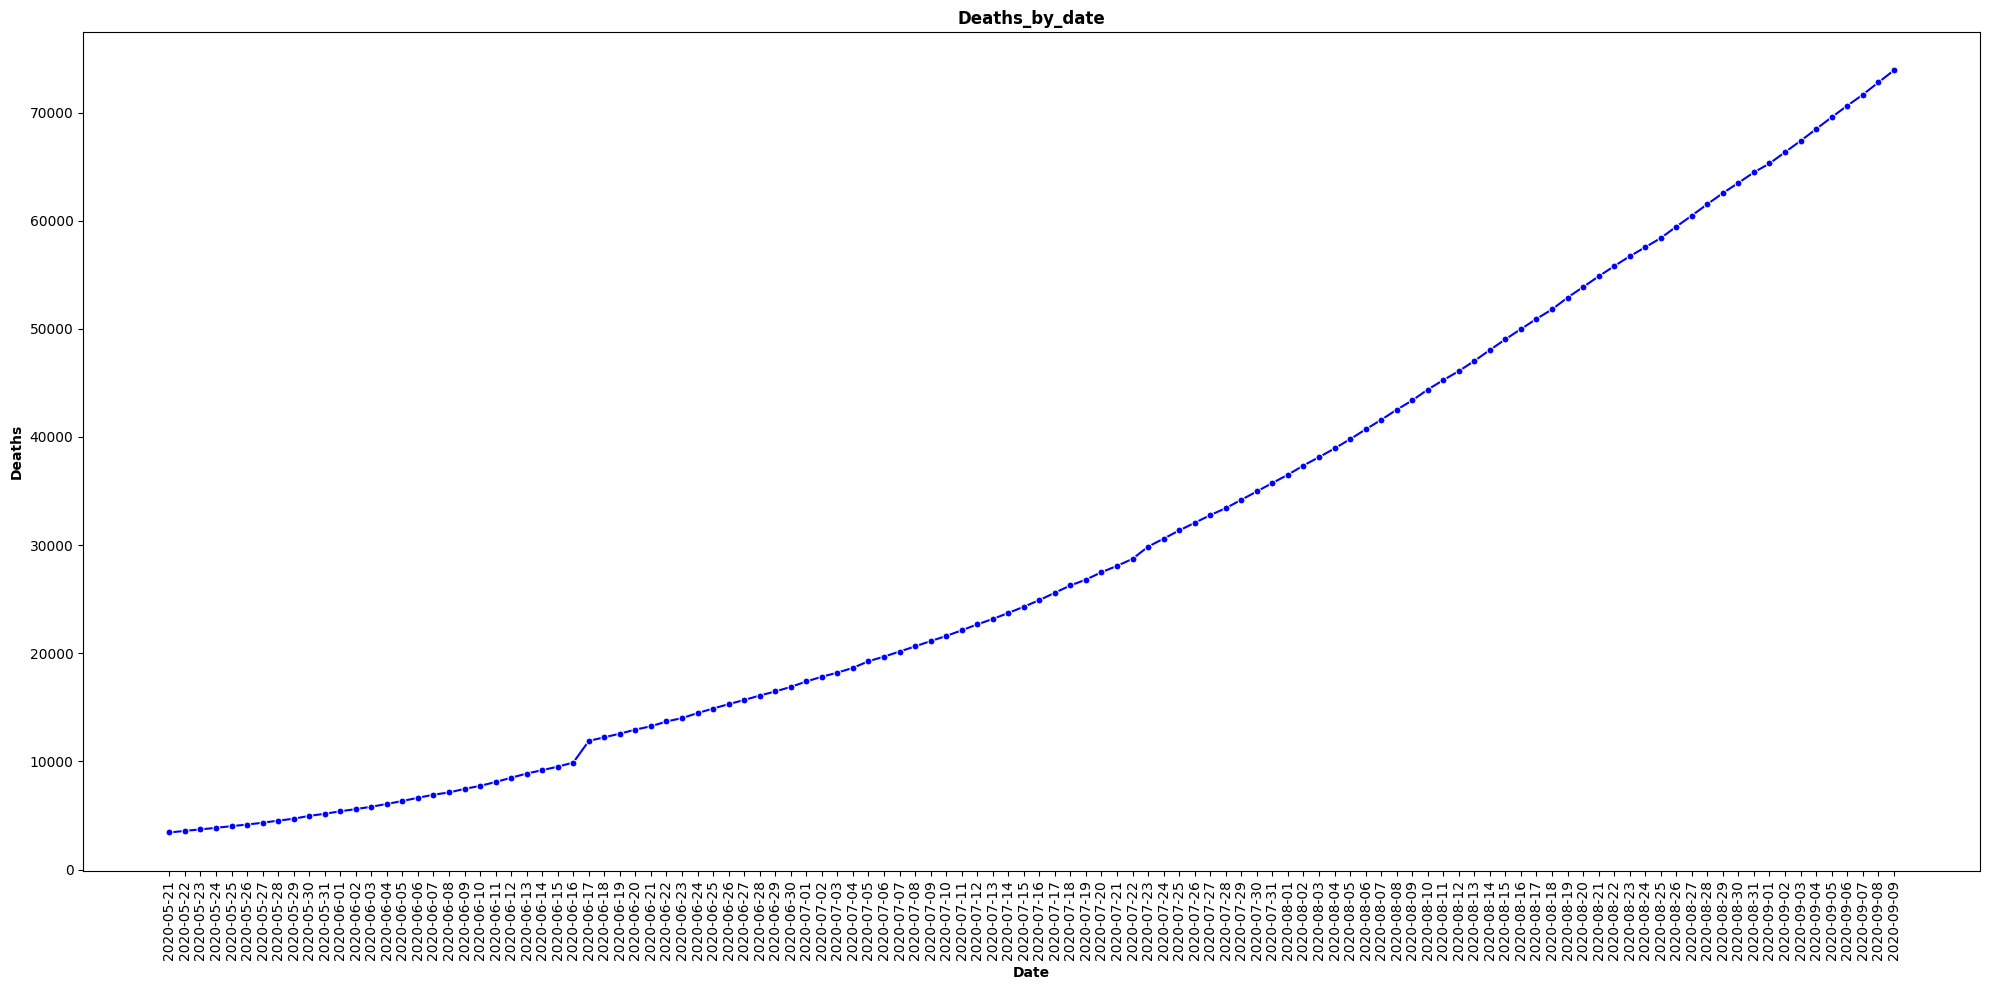

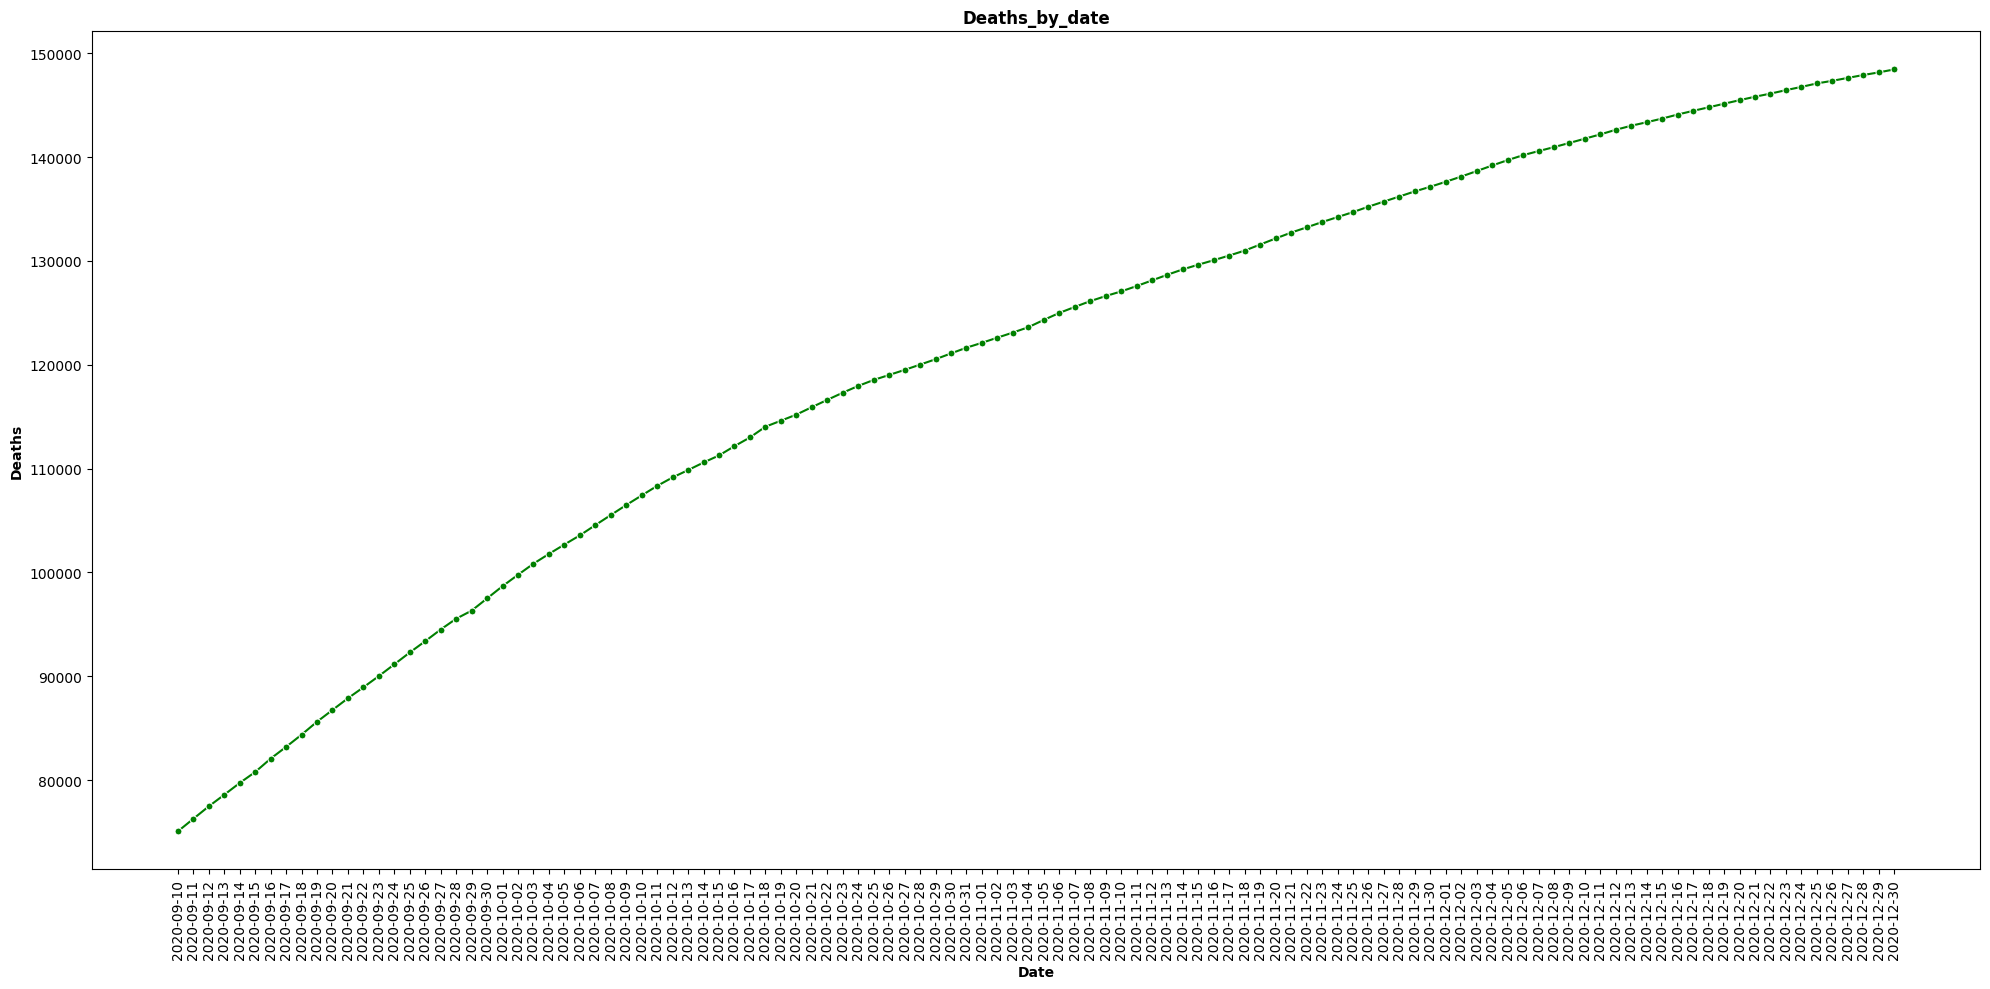

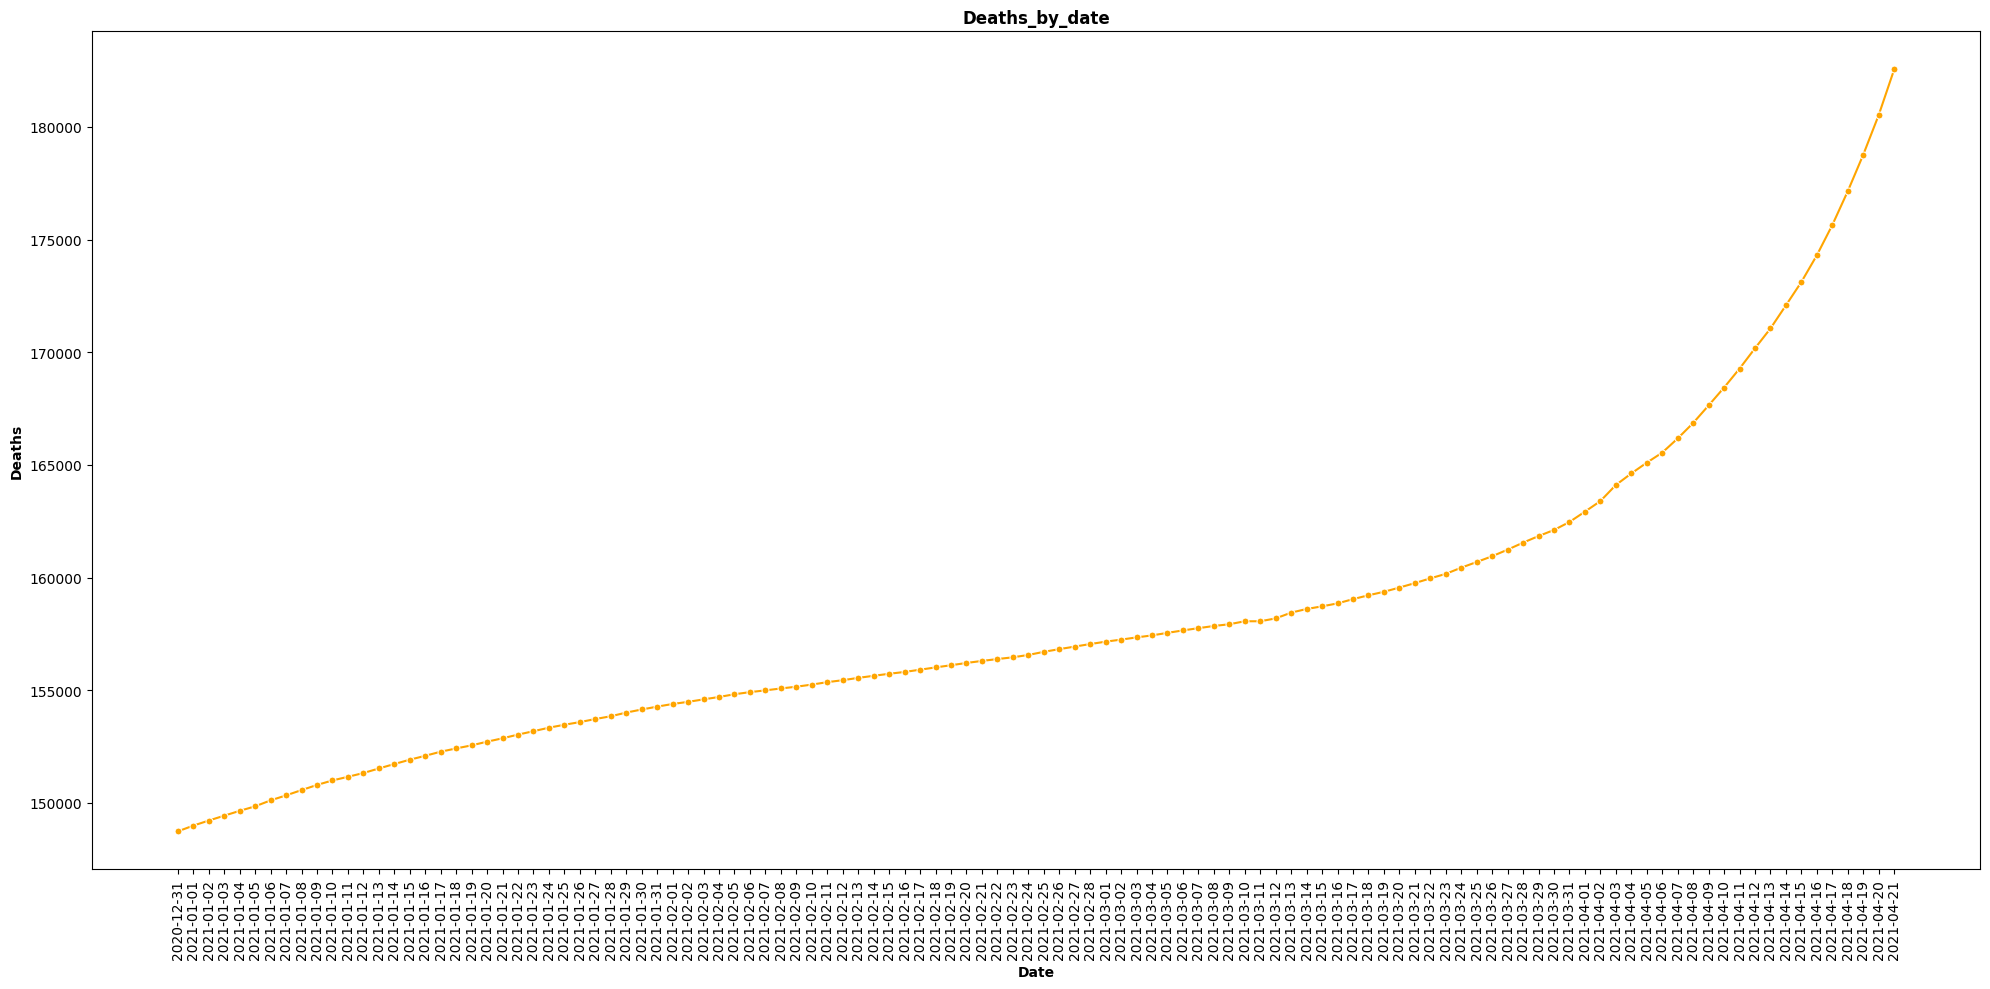

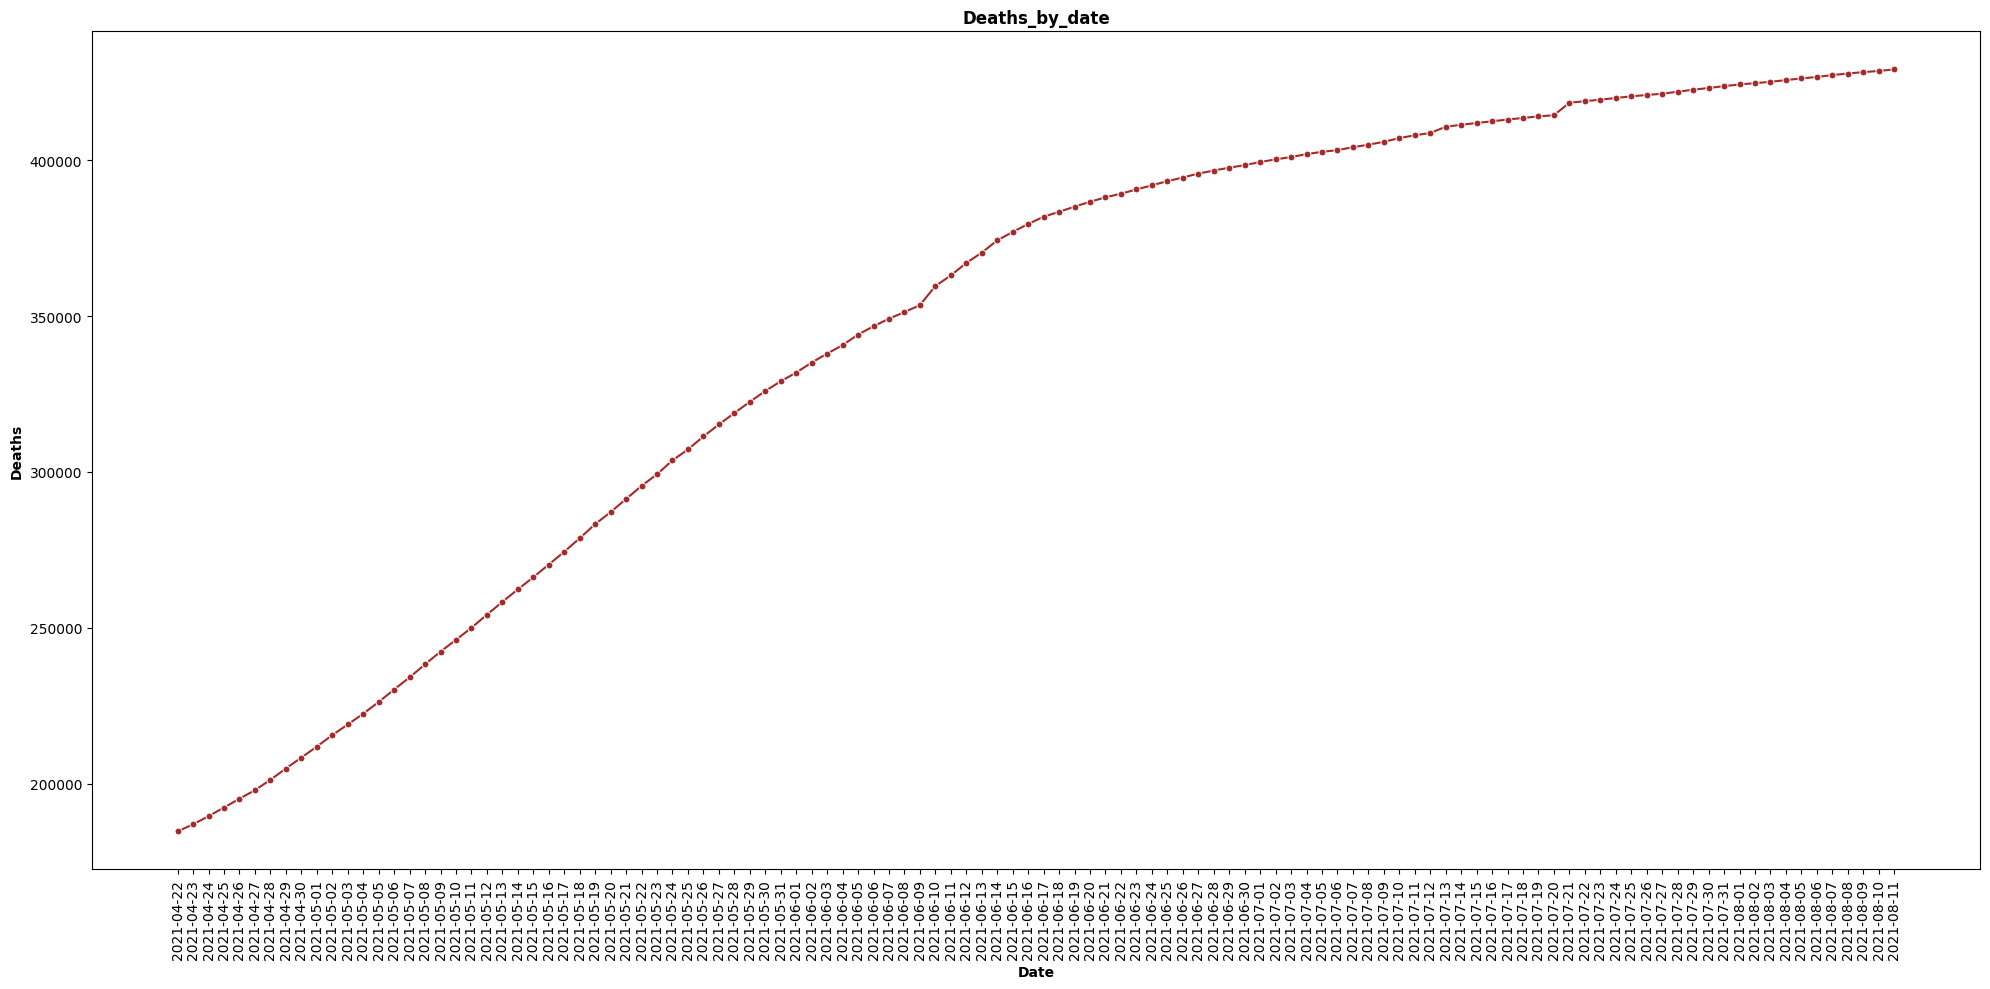

In [16]:
# Visualize the deaths by date data
create_lineplot(death_by_date, 0, 112,'Date','Deaths','Deaths_by_date',20,10,color='red')
create_lineplot(death_by_date, 112, 224,'Date','Deaths','Deaths_by_date',20,10,color='blue')
create_lineplot(death_by_date, 224, 336,'Date','Deaths','Deaths_by_date',20,10,color='green')
create_lineplot(death_by_date, 336, 448,'Date','Deaths','Deaths_by_date',20,10,color='orange')
create_lineplot(death_by_date, 448, 560,'Date','Deaths','Deaths_by_date',20,10,color='brown')


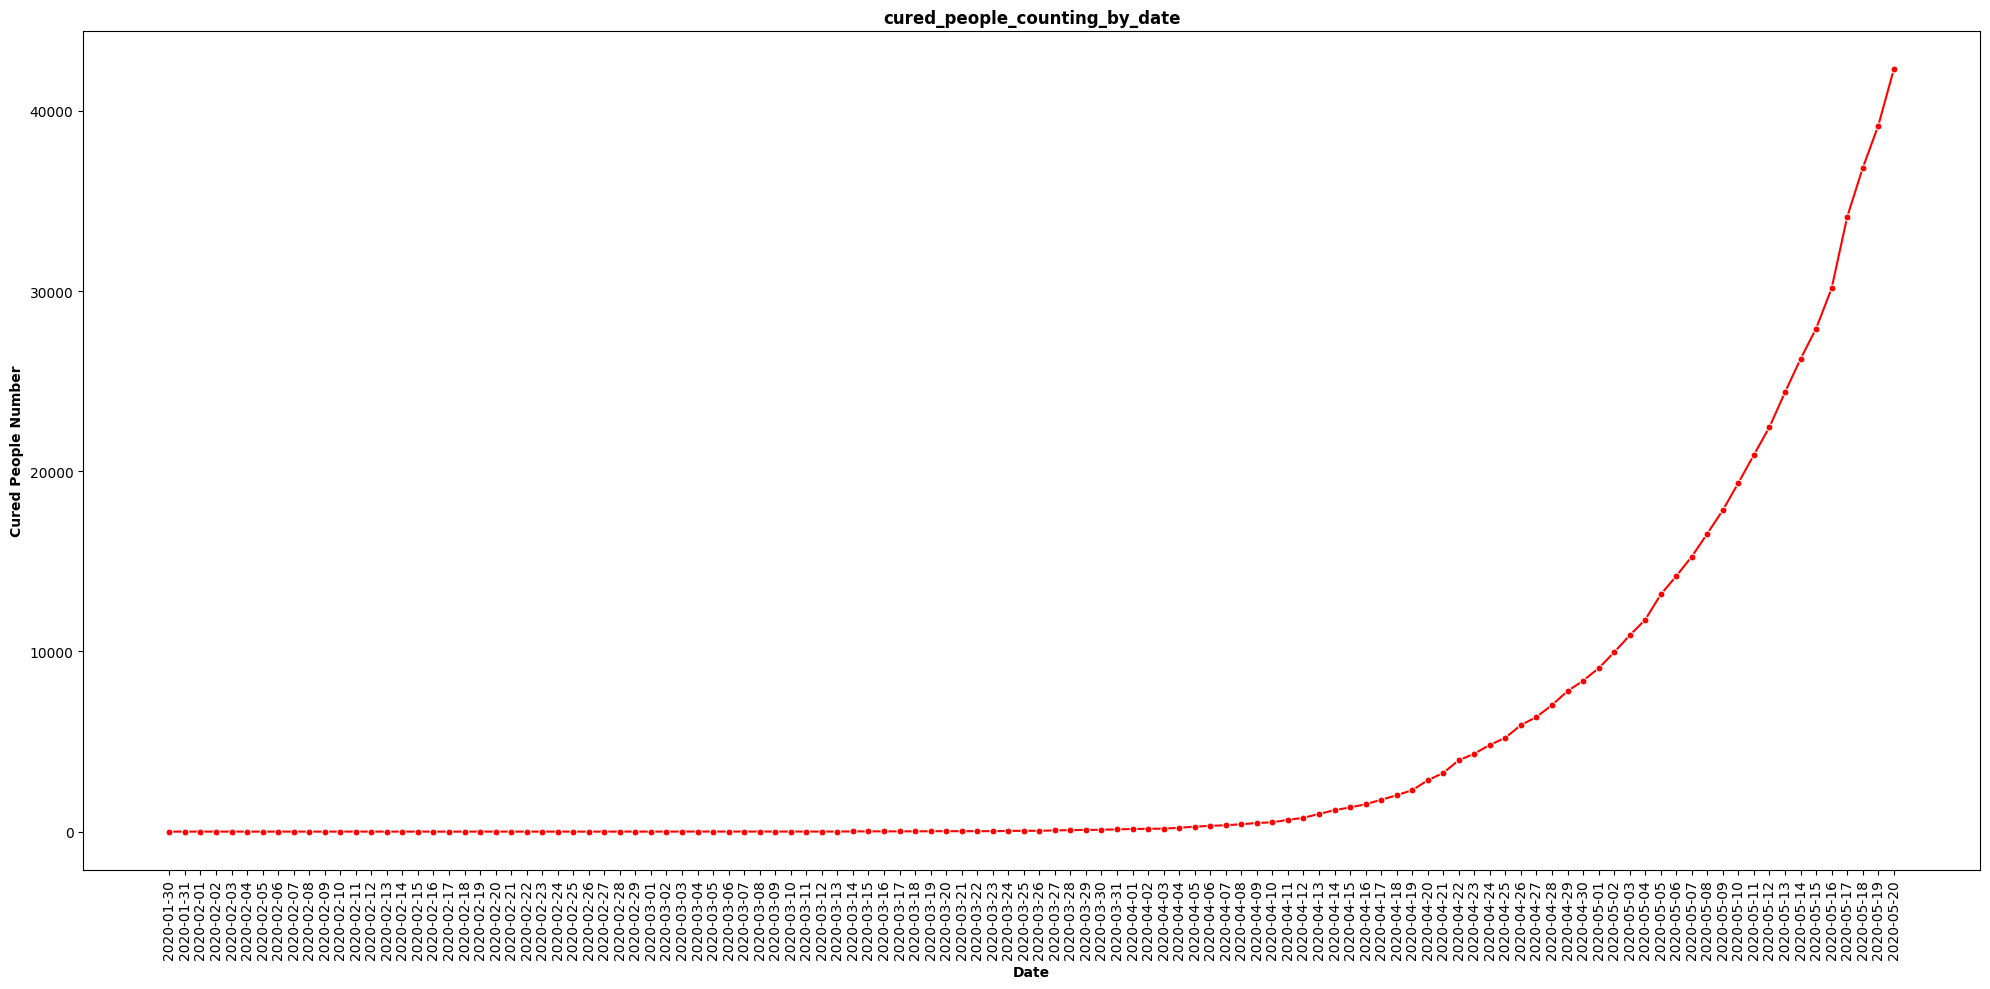

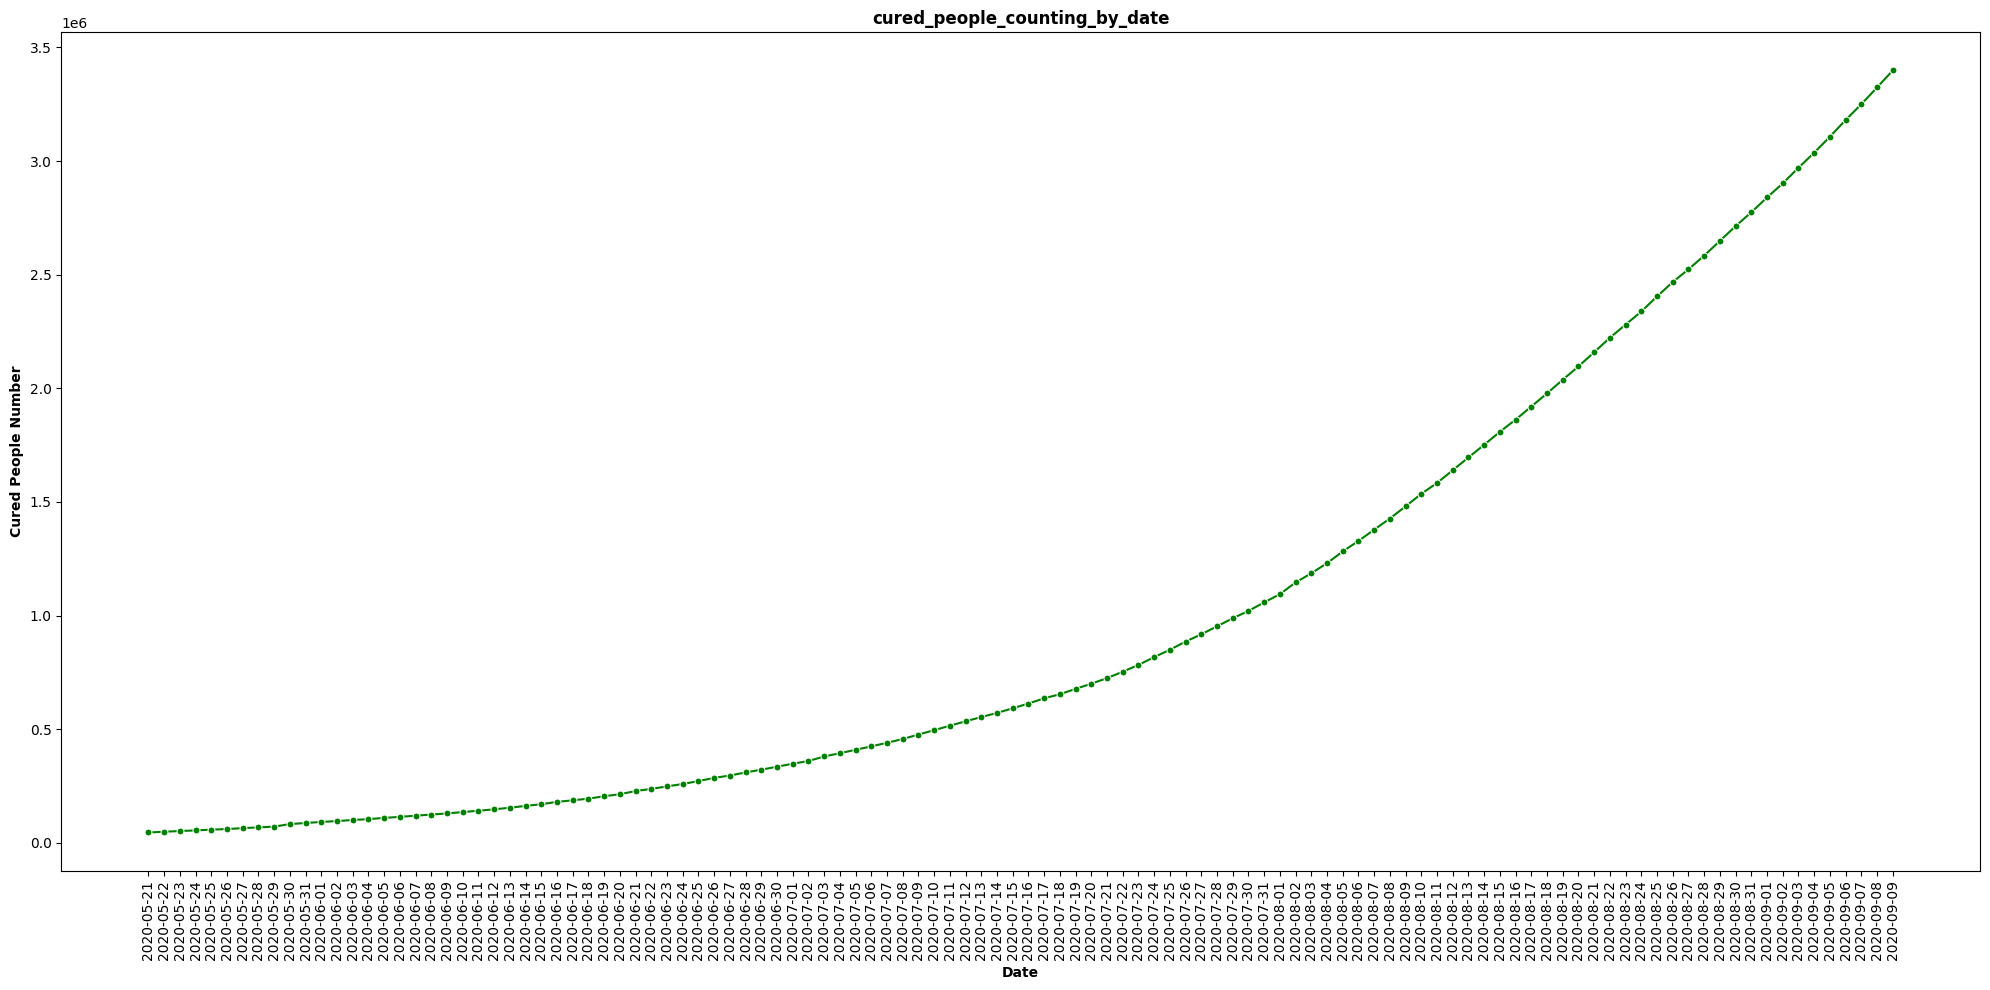

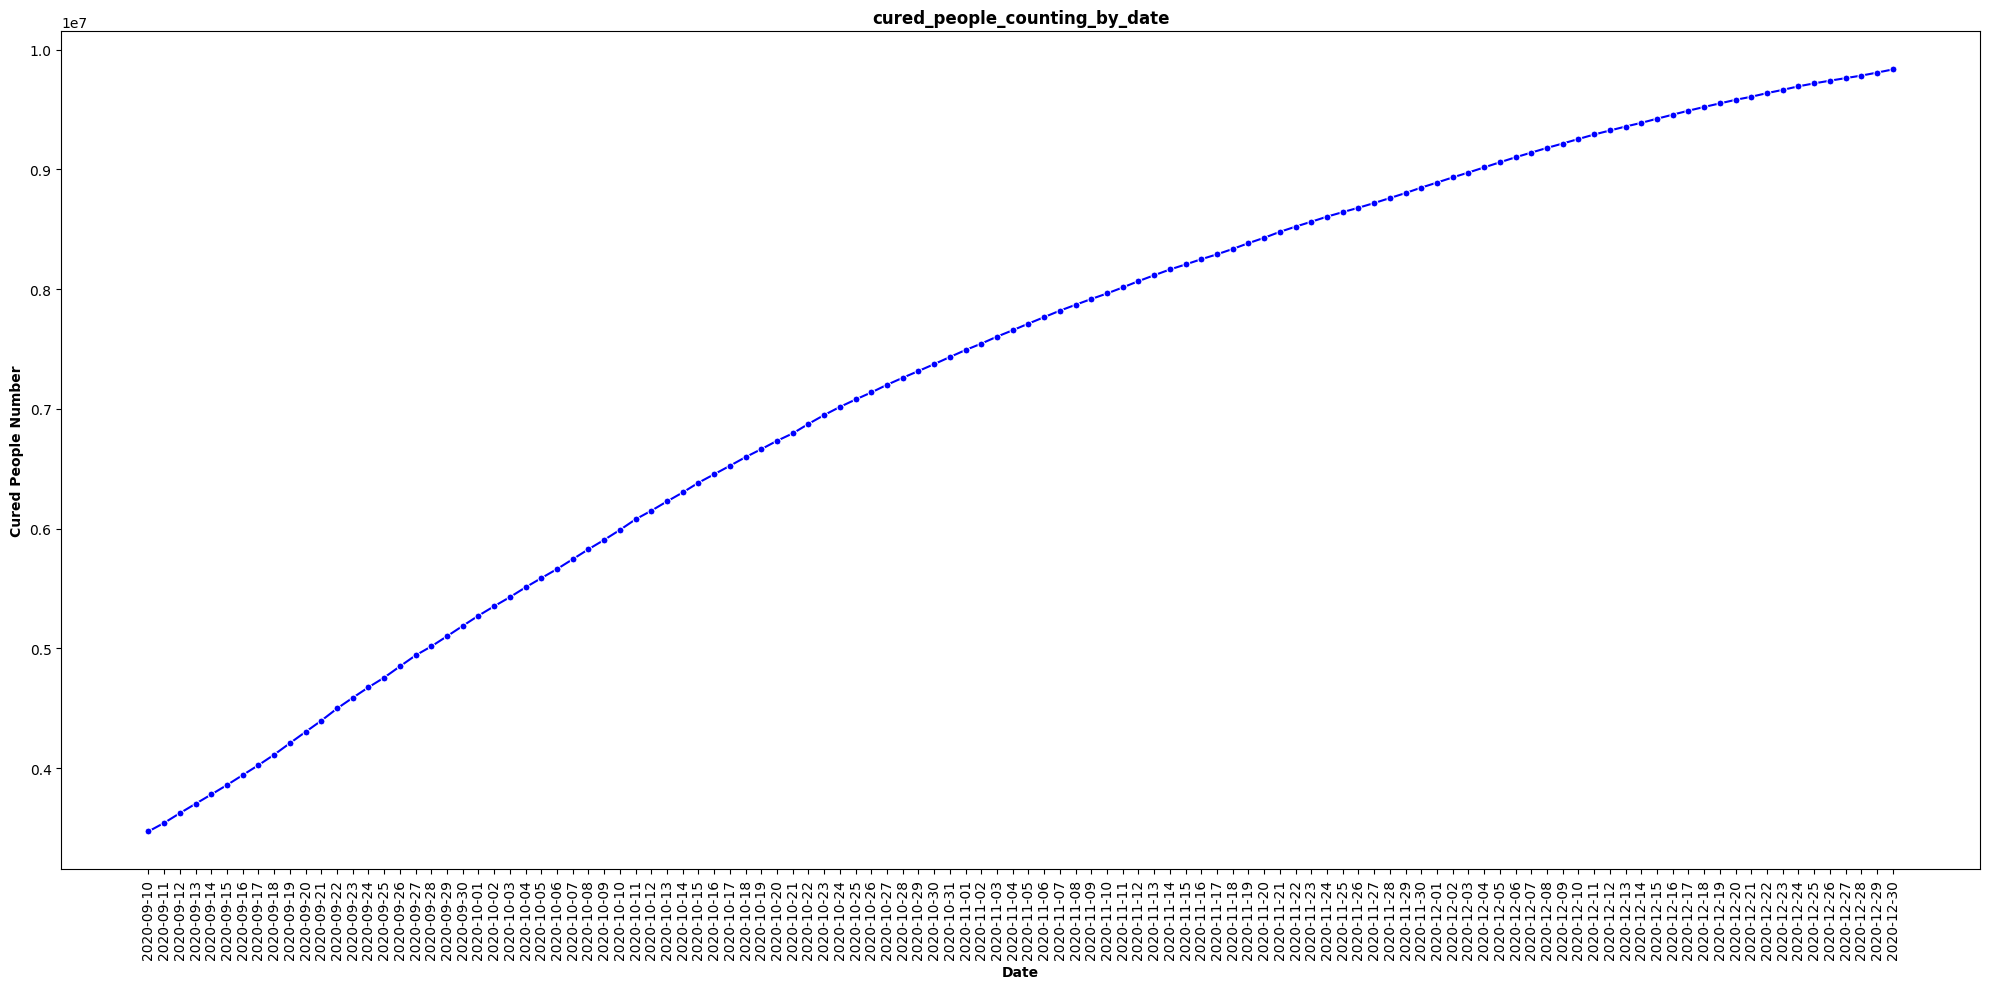

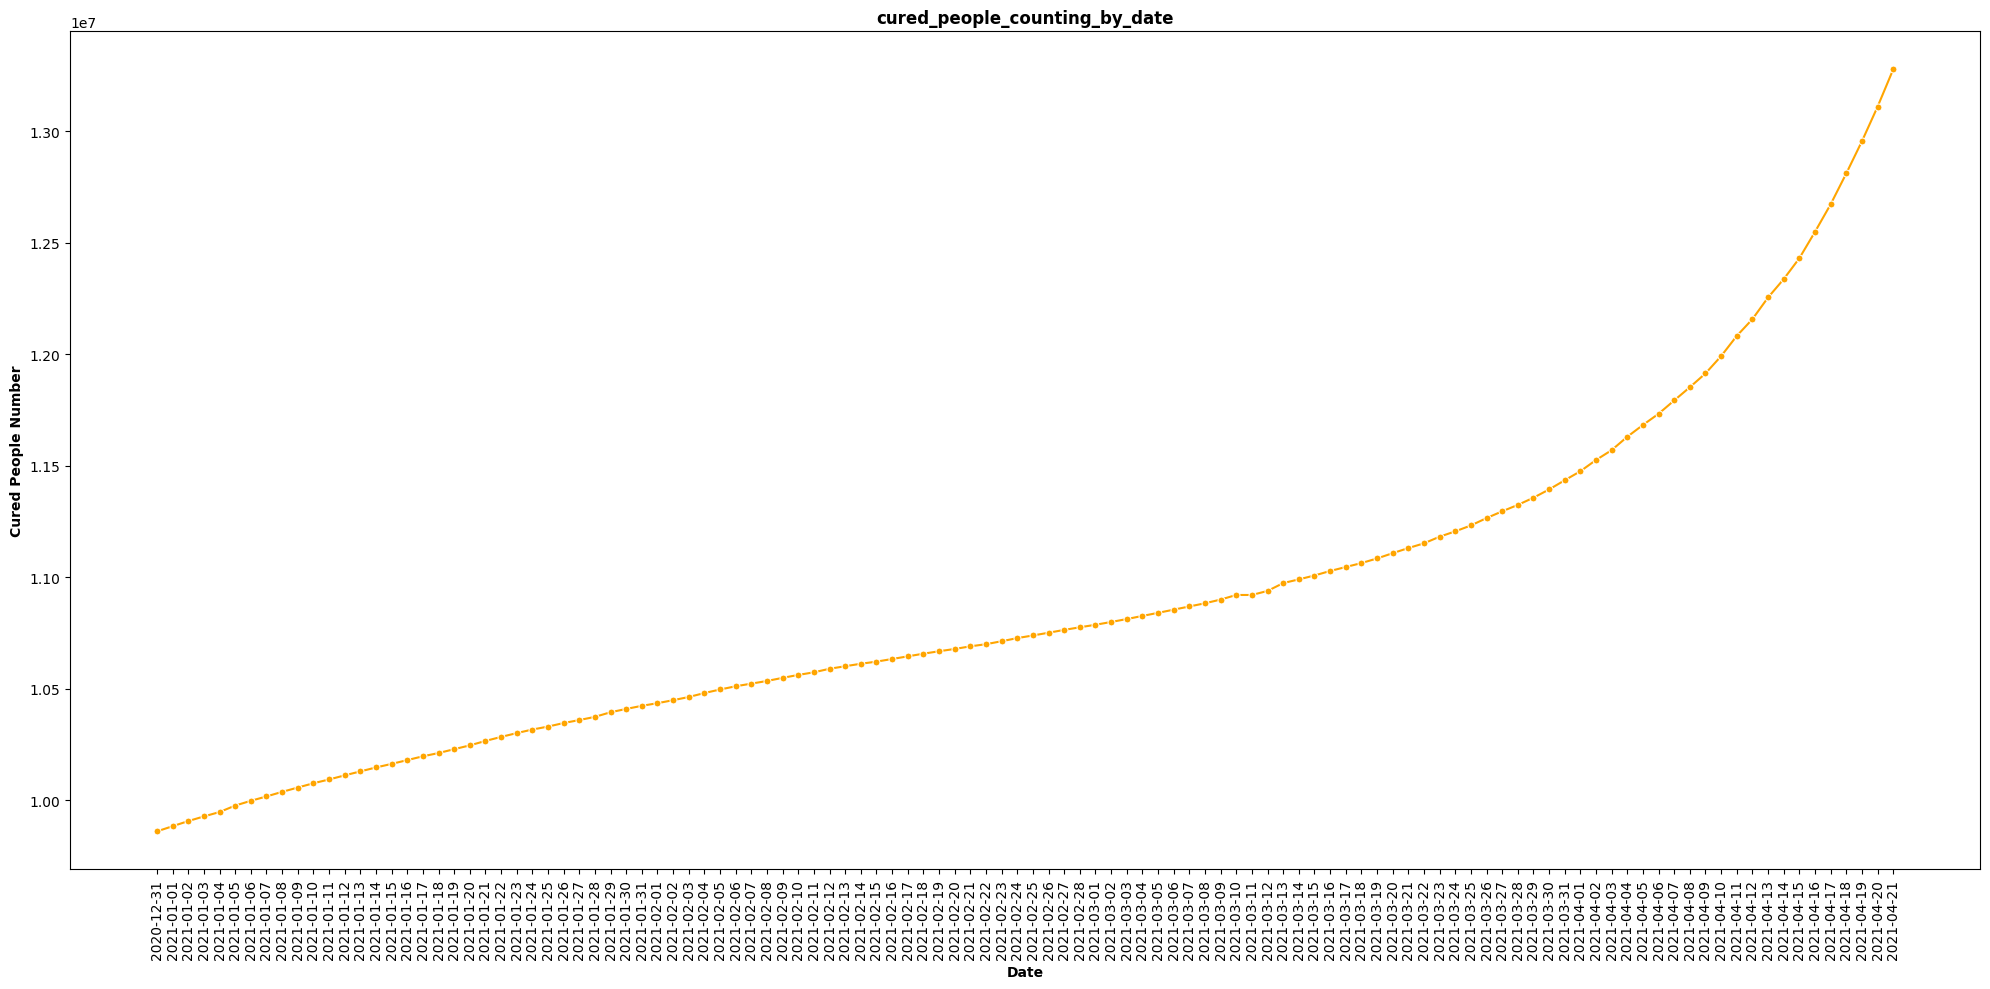

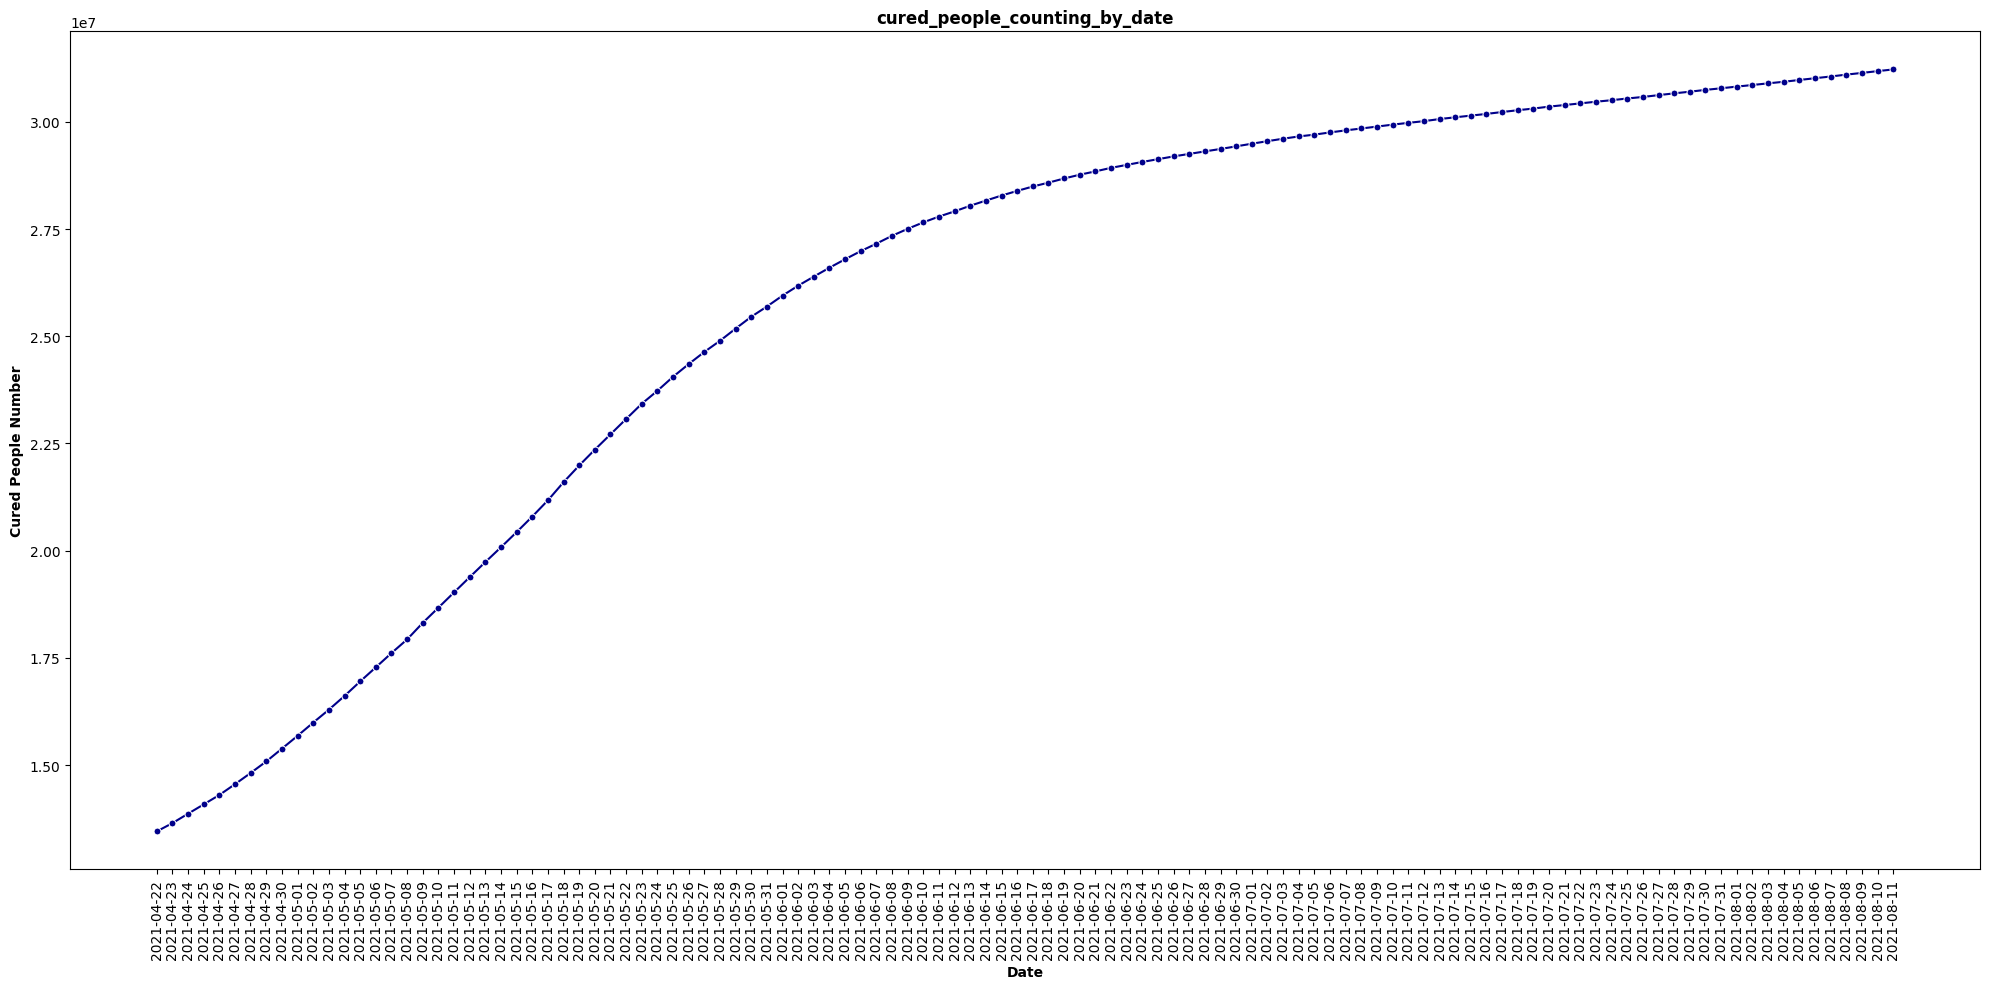

In [31]:
# Visualize the cured people count by date data
create_lineplot(cured_by_date, 0, 112,'Date','Cured People Number','cured_people_counting_by_date',20,10,color='red')
create_lineplot(cured_by_date, 112, 224,'Date','Cured People Number','cured_people_counting_by_date',20,10,color='green')
create_lineplot(cured_by_date, 224, 336,'Date','Cured People Number','cured_people_counting_by_date',20,10,color='blue')
create_lineplot(cured_by_date, 336, 448,'Date','Cured People Number','cured_people_counting_by_date',20,10,color='orange')
create_lineplot(cured_by_date, 448, 560,'Date','Cured People Number','cured_people_counting_by_date',20,10,color='darkblue')

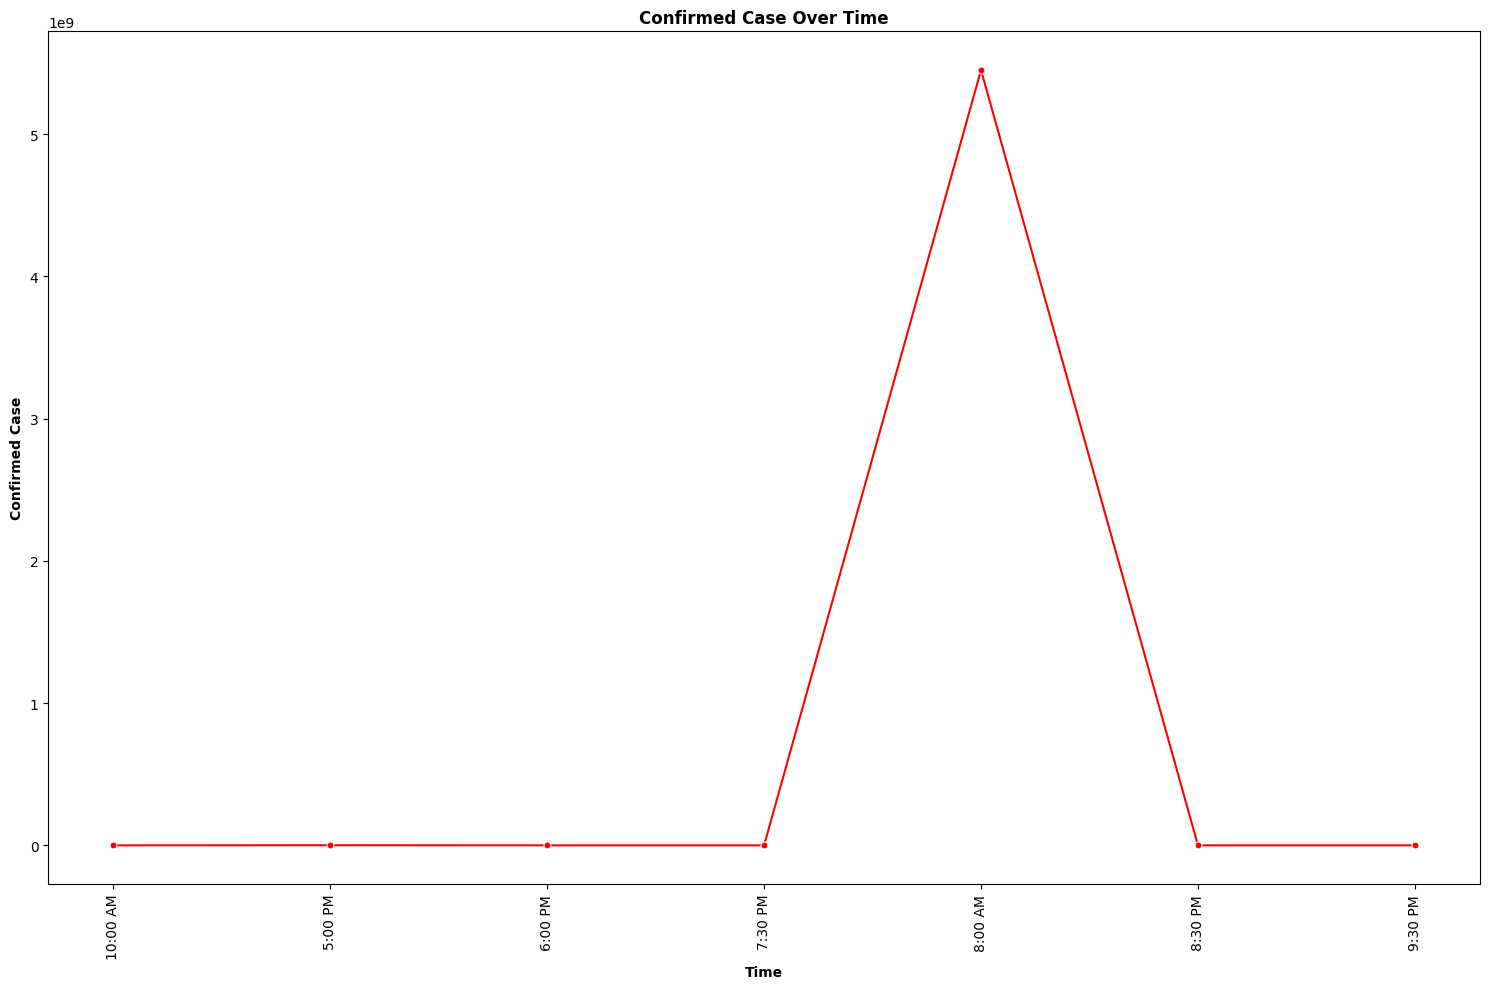

In [30]:
create_lineplot(confirmed_case_by_time, 0, 7,'Time','Confirmed Case','Confirmed Case Over Time',15,10,color='red')

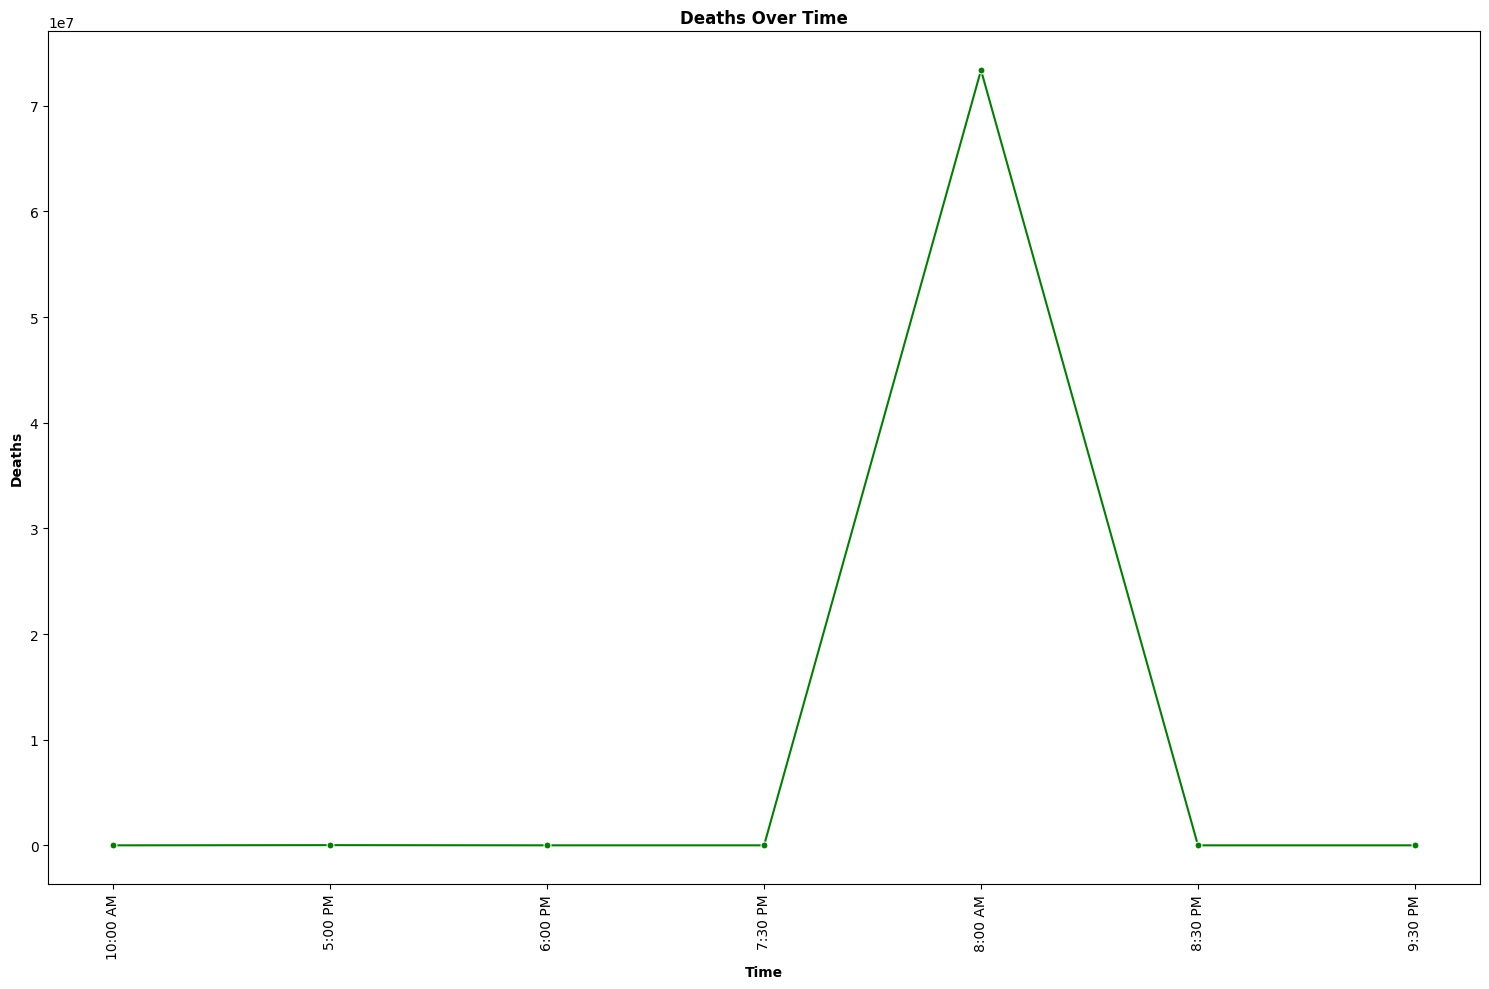

In [29]:
create_lineplot(death_by_time,0,7,'Time','Deaths','Deaths Over Time',15,10,'green')

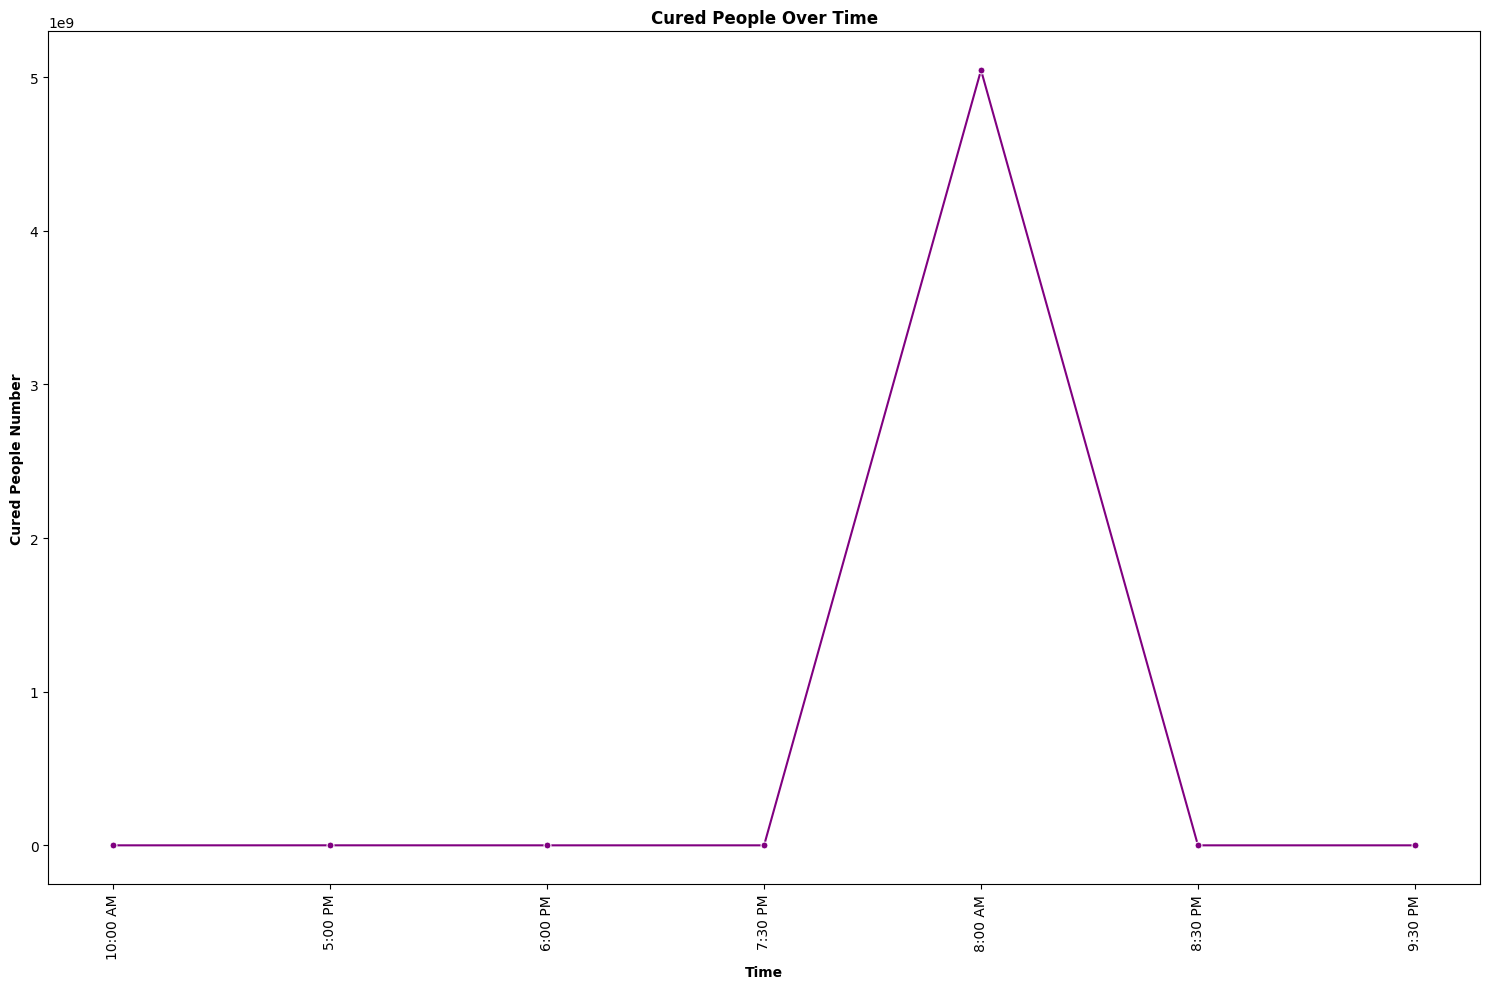

In [33]:
create_lineplot(cured_by_time,0,7,'Time','Cured People Number','Cured People Over Time',15,10,'purple')

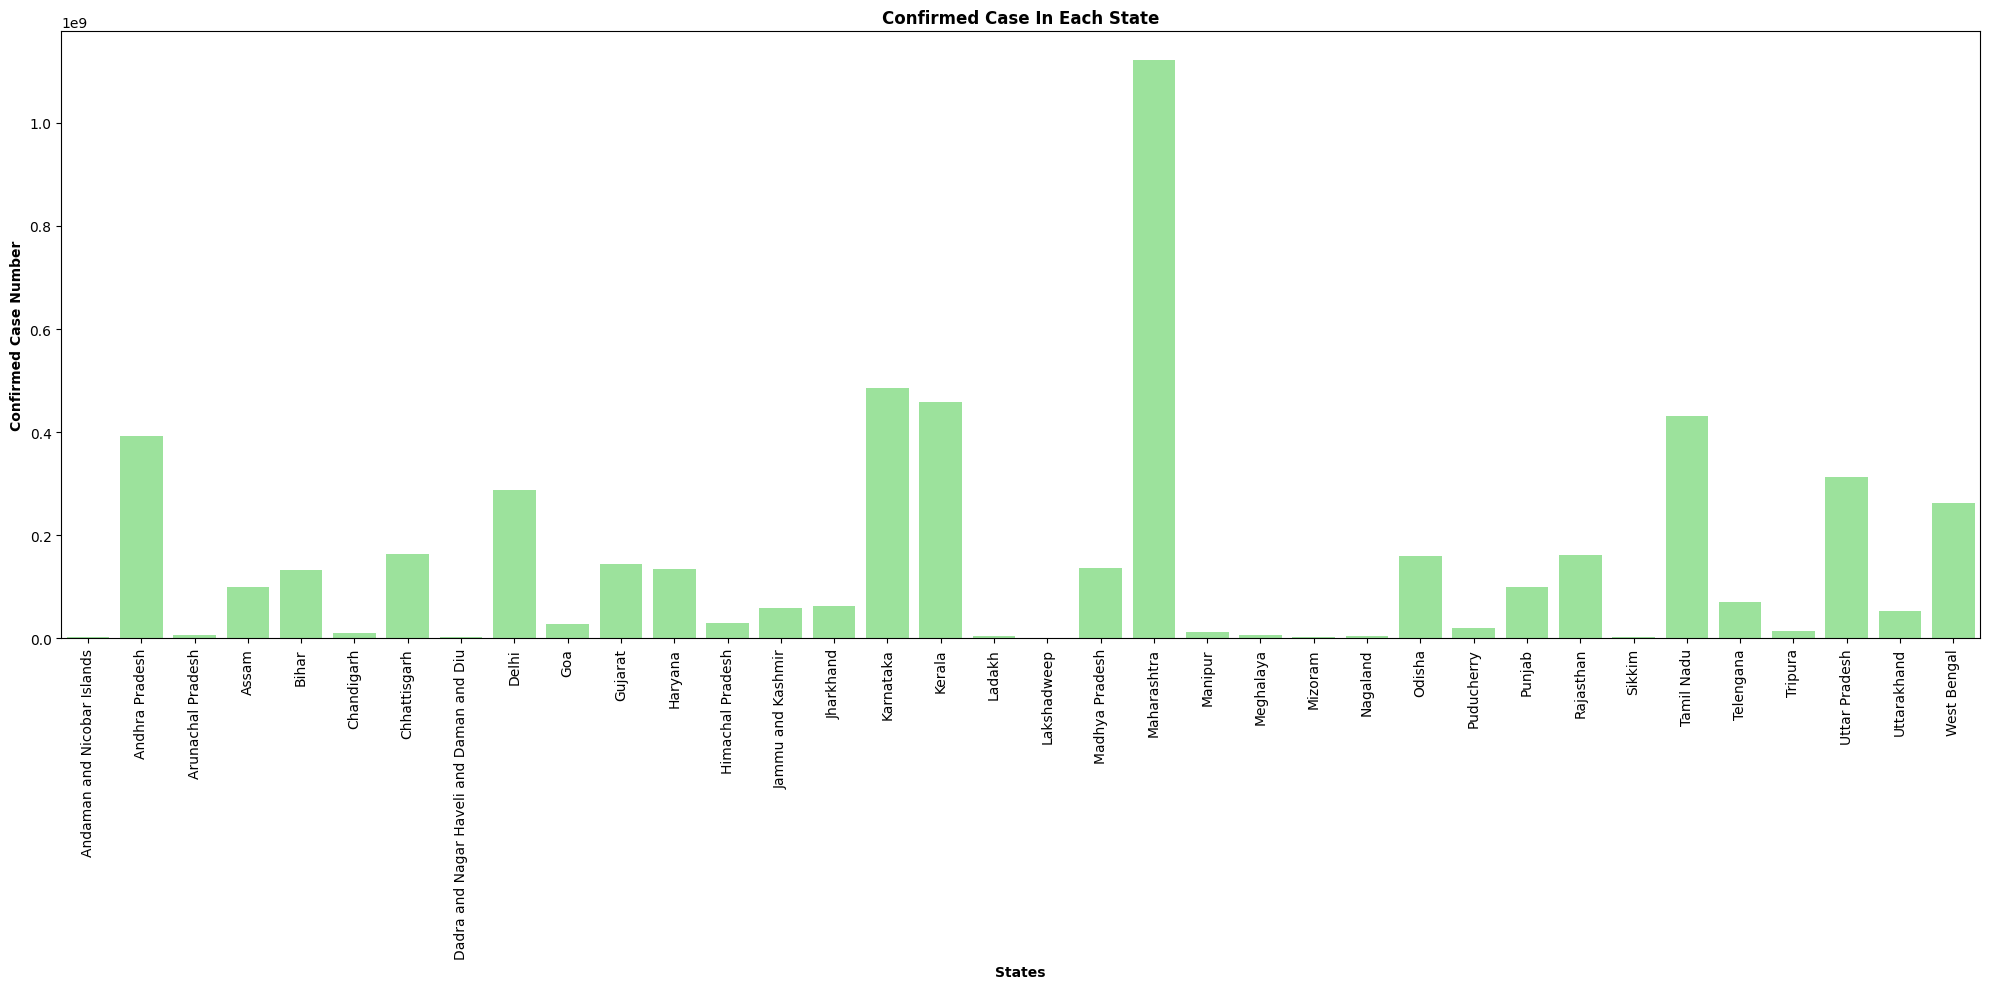